# Open Source Libraries in APK Files — Single Dataset GitHub Enrichment

This notebook analyzes one input dataset, `dataset_700.csv`, enriches each GitHub repository with GitHub API metadata, and stores results incrementally in `../database/` so interrupted runs can resume without refetching already processed repositories.

Main additions in this version:

- Uses **one dataset only**: `dataset_700.csv`.
- Removes trend analysis by APK collection size.
- Supports authenticated GitHub REST API calls through `GITHUB_TOKEN`.
- Saves each repository result to the CSV cache **immediately after it is fetched**.
- Reuses cached rows and fetches only missing repositories.
- Computes repo-level metrics grouped into:
  - Library Popularity
  - Repository Activity Metrics
  - Fragility Metrics


## 1. Setup

Expected project structure:

```text
project_root/
├── analysis_datasets/
│   └── dataset_700.csv
├── database/
│   └── github_repo_metrics_cache.csv      # created automatically
└── notebooks/
    └── this_notebook.ipynb
```

If your notebook is in the project root instead of a `notebooks/` folder, adjust `PROJECT_ROOT`, `ANALYSIS_DATASETS_DIR`, and `DATABASE_DIR` below.

### GitHub authentication

This notebook reads `GITHUB_TOKEN` from a `.env` file at `../.env`, relative to `PROJECT_ROOT`. Add a line like this to that file:

```bash
GITHUB_TOKEN=ghp_your_token_here
```

For public repositories, a fine-grained token with read-only public access is enough. Do not hard-code your token inside this notebook.



In [78]:
import os
import re
import json
import time
import math
import subprocess
from pathlib import Path
from datetime import datetime, timezone
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 160)

# -------------------------------------------------------------------
# Paths
# -------------------------------------------------------------------
# Use the current working directory as default. If this notebook lives
# inside ./notebooks, uncomment the next line instead:
# PROJECT_ROOT = Path.cwd().resolve().parent
PROJECT_ROOT = Path.cwd().resolve()

ANALYSIS_DATASETS_DIR = PROJECT_ROOT / '..' / 'analysis_datasets'
OUTPUT_DIR = PROJECT_ROOT / '..' / 'analysis_outputs'
DATABASE_DIR = PROJECT_ROOT / '..' / 'database'

DATASET_FILE = ANALYSIS_DATASETS_DIR / 'dataset_700.csv'
TAGGED_APPS_FILE = DATABASE_DIR / 'tagged_apps.csv'
CACHE_FILE = DATABASE_DIR / 'github_repo_metrics_cache.csv'
FAILED_REPOS_FILE = DATABASE_DIR / 'github_repo_metrics_failed.csv'
ENV_FILE = PROJECT_ROOT / '..' / '.env'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATABASE_DIR.mkdir(parents=True, exist_ok=True)


def load_env_file(path: Path) -> dict:
    """Load simple KEY=VALUE pairs from a .env file into os.environ."""
    loaded = {}
    if not path.exists():
        return loaded

    for raw_line in path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        if key:
            os.environ.setdefault(key, value)
            loaded[key] = value
    return loaded


ENV_VARS = load_env_file(ENV_FILE)
GITHUB_TOKEN = os.environ.get('GITHUB_TOKEN')


def save_current_figure(filename: str, output_dir: Path = OUTPUT_DIR, dpi: int = 300) -> Path:
    """Save the current matplotlib figure to OUTPUT_DIR as a PNG and return its path."""
    output_dir.mkdir(parents=True, exist_ok=True)
    path = output_dir / filename
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    print('Saved figure:', path)
    return path


print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATASET_FILE:', DATASET_FILE)
print('TAGGED_APPS_FILE:', TAGGED_APPS_FILE)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('DATABASE_DIR:', DATABASE_DIR)
print('CACHE_FILE:', CACHE_FILE)
print('ENV_FILE:', ENV_FILE)
print('GITHUB_TOKEN loaded from .env or environment:', bool(GITHUB_TOKEN))


PROJECT_ROOT: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook
DATASET_FILE: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_datasets/dataset_700.csv
TAGGED_APPS_FILE: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../database/tagged_apps.csv
OUTPUT_DIR: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs
DATABASE_DIR: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../database
CACHE_FILE: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../database/github_repo_metrics_cache.csv
ENV_FILE: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-S

## 2. Load `dataset_700.csv` and transform origin

The `origin` column can contain values such as:

- `fingerprints`
- `license_exposure`
- `fingerprints,license_exposure`

We transform it into two binary columns:

- `origin_fingerprint`
- `origin_license_exposure`


In [79]:
def load_dataset(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'Dataset not found: {path}')

    df = pd.read_csv(path)

    # Normalize expected columns in case of small spelling differences.
    if 'library_key' not in df.columns and 'libarary_key' in df.columns:
        # Keep original spelling too, because existing code may reference it.
        df['library_key'] = df['libarary_key']

    required = ['pkg_name', 'repo_url', 'cited', 'origin']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}')

    df['origin'] = df['origin'].fillna('').astype(str)
    df['origin_fingerprint'] = df['origin'].str.contains('fingerprints', case=False, na=False).astype(int)
    df['origin_license_exposure'] = df['origin'].str.contains('license_exposure', case=False, na=False).astype(int)
    df['cited'] = pd.to_numeric(df['cited'], errors='coerce').fillna(0).astype(int)

    return df

raw_df = load_dataset(DATASET_FILE)
print(raw_df.shape)
raw_df.head()


(108234, 16)


,pkg_name,repo_host,repo_path,repo_url,cited,origin,libarary_key,library_name,smali_prefix,fingerprint_types,classes_matched,sample_class,sample_class_file,library_key,origin_fingerprint,origin_license_exposure
0,ai.asleep.sleepstar,github.com,BoltsFramework/Bolts-Android,https://github.com/BoltsFramework/Bolts-Android,1,fingerprints,BoltsFramework/Bolts-Android,Bolts-Android,Lbolts/,java_package,36.0,Lbolts/AggregateException;,data/decoded/ai.asleep.sleepstar/smali_classes...,BoltsFramework/Bolts-Android,1,0
1,ai.asleep.sleepstar,github.com,CanHub/Android-Image-Cropper,https://github.com/CanHub/Android-Image-Cropper,1,fingerprints,CanHub/Android-Image-Cropper,Android-Image-Cropper,Lcom/canhub/cropper/,kotlin_package,86.0,Lcom/canhub/cropper/BitmapCroppingWorkerJob$Re...,data/decoded/ai.asleep.sleepstar/smali_classes...,CanHub/Android-Image-Cropper,1,0
2,ai.asleep.sleepstar,github.com,CanHub/Android-Image-Cropper,https://github.com/CanHub/Android-Image-Cropper,1,fingerprints,CanHub/Android-Image-Cropper,Android-Image-Cropper,Lcom/canhub/cropper/utils/,kotlin_package,2.0,Lcom/canhub/cropper/utils/GetFilePathFromUriKt;,data/decoded/ai.asleep.sleepstar/smali_classes...,CanHub/Android-Image-Cropper,1,0
3,ai.asleep.sleepstar,github.com,JetBrains/java-annotations,https://github.com/JetBrains/java-annotations,1,fingerprints,JetBrains/java-annotations,java-annotations,Lorg/jetbrains/annotations/,java_package,30.0,Lorg/jetbrains/annotations/ApiStatus$Available...,data/decoded/ai.asleep.sleepstar/smali_classes...,JetBrains/java-annotations,1,0
4,ai.asleep.sleepstar,github.com,JetBrains/java-annotations,https://github.com/JetBrains/java-annotations,1,fingerprints,JetBrains/java-annotations,java-annotations,Lorg/intellij/lang/annotations/,java_package,27.0,Lorg/intellij/lang/annotations/Flow;,data/decoded/ai.asleep.sleepstar/smali_classes...,JetBrains/java-annotations,1,0


## 3. Normalize GitHub repository identifiers

The dataset may contain GitHub URLs in different fields and formats, for example:

- `https://github.com/square/okio`
- `git+https://github.com/square/okio.git`
- `{'type': 'git', 'url': 'https://github.com/microsoft/react-native-code-push.git'}`
- `square/okio`

The functions below extract a canonical `owner/repo` value named `github_repo_full_name`.


In [80]:

def clean_repo_name(owner: str, repo: str) -> str | None:
    if not owner or not repo:
        return None
    owner = str(owner).strip().strip('/').strip()
    repo = str(repo).strip().strip('/').strip()
    repo = re.sub(r'\.git$', '', repo, flags=re.IGNORECASE)
    repo = repo.split('#')[0].split('?')[0]
    if not owner or not repo:
        return None
    if owner.lower() in {'http:', 'https:', 'github.com', 'www.github.com'}:
        return None
    return f'{owner}/{repo}'


def extract_github_repo_from_text(value) -> str | None:
    # Extract canonical owner/repo from a repo_url-like field.
    if pd.isna(value):
        return None

    text = str(value).strip()
    if not text or text.lower() in {'nan', 'none', 'null'}:
        return None

    # Some rows contain Python-dict-like text with a GitHub URL inside.
    m = re.search(r'https?://github\.com[:/]+([^\s\'\"{}]+)', text, flags=re.IGNORECASE)
    if m:
        parts = m.group(1).strip('/').split('/')
        if len(parts) >= 2:
            return clean_repo_name(parts[0], parts[1])

    # git@github.com:owner/repo.git
    m = re.search(r'git@github\.com:([^/\s]+)/([^\s\'\"]+)', text, flags=re.IGNORECASE)
    if m:
        return clean_repo_name(m.group(1), m.group(2))

    # github.com/owner/repo without protocol
    m = re.search(r'github\.com[:/]+([^/\s]+)/([^\s\'\"]+)', text, flags=re.IGNORECASE)
    if m:
        return clean_repo_name(m.group(1), m.group(2))

    # Plain owner/repo, but avoid JSON-looking, URL-looking, or path-looking values.
    if re.match(r'^[A-Za-z0-9_.-]+/[A-Za-z0-9_.-]+(?:\.git)?$', text):
        owner, repo = text.split('/', 1)
        return clean_repo_name(owner, repo)

    return None


def add_github_repo_identifier(df: pd.DataFrame) -> pd.DataFrame:
    candidate_cols = [
        col for col in ['repo_url', 'repo_path', 'library_key', 'libarary_key']
        if col in df.columns
    ]

    df = df.copy()
    df['github_repo_full_name'] = None

    for col in candidate_cols:
        extracted = df[col].apply(extract_github_repo_from_text)
        df['github_repo_full_name'] = df['github_repo_full_name'].where(
            df['github_repo_full_name'].notna(), extracted
        )

    return df


df = add_github_repo_identifier(raw_df)
print('Rows:', len(df))
print('Rows with GitHub repo:', df['github_repo_full_name'].notna().sum())
print('Unique GitHub repos:', df['github_repo_full_name'].nunique())
df[['pkg_name', 'repo_url', 'repo_path' if 'repo_path' in df.columns else 'repo_url', 'github_repo_full_name']].head(10)


Rows: 108234
Rows with GitHub repo: 106368
Unique GitHub repos: 274


,pkg_name,repo_url,repo_path,github_repo_full_name
0,ai.asleep.sleepstar,https://github.com/BoltsFramework/Bolts-Android,BoltsFramework/Bolts-Android,BoltsFramework/Bolts-Android
1,ai.asleep.sleepstar,https://github.com/CanHub/Android-Image-Cropper,CanHub/Android-Image-Cropper,CanHub/Android-Image-Cropper
2,ai.asleep.sleepstar,https://github.com/CanHub/Android-Image-Cropper,CanHub/Android-Image-Cropper,CanHub/Android-Image-Cropper
3,ai.asleep.sleepstar,https://github.com/JetBrains/java-annotations,JetBrains/java-annotations,JetBrains/java-annotations
4,ai.asleep.sleepstar,https://github.com/JetBrains/java-annotations,JetBrains/java-annotations,JetBrains/java-annotations
5,ai.asleep.sleepstar,https://github.com/InsertKoinIO/koin,InsertKoinIO/koin,InsertKoinIO/koin
6,ai.asleep.sleepstar,https://github.com/InsertKoinIO/koin,InsertKoinIO/koin,InsertKoinIO/koin
7,ai.asleep.sleepstar,https://github.com/InsertKoinIO/koin,InsertKoinIO/koin,InsertKoinIO/koin
8,ai.asleep.sleepstar,https://github.com/InsertKoinIO/koin,InsertKoinIO/koin,InsertKoinIO/koin
9,ai.asleep.sleepstar,https://github.com/InsertKoinIO/koin,InsertKoinIO/koin,InsertKoinIO/koin


## 4. Base repository-level metrics from the APK dataset

Before calling GitHub, we compute dataset-derived metrics for every repository.

### Library Popularity metrics from the APK collection

These reflect popularity **inside your APK collection**, not global GitHub popularity:

- `library_occurrences`: total rows for this repo
- `apk_count`: number of APKs where this repo appears
- `apk_coverage_ratio`: APKs containing this repo / total APKs
- `cited_count`: number of rows with `cited = 1`
- `cited_ratio`: cited rows / total rows for this repo
- `fingerprint_origin_count`
- `license_exposure_origin_count`
- `fingerprint_origin_ratio`
- `license_exposure_origin_ratio`
- `fingerprint_type_count`
- `dominant_fingerprint_type`


In [81]:
def make_repo_dataset_metrics(df: pd.DataFrame) -> pd.DataFrame:
    github_df = df[df['github_repo_full_name'].notna()].copy()
    total_apks = df['pkg_name'].nunique()

    group = github_df.groupby('github_repo_full_name', dropna=False)

    metrics = group.agg(
        library_occurrences=('github_repo_full_name', 'size'),
        apk_count=('pkg_name', 'nunique'),
        cited_count=('cited', 'sum'),
        fingerprint_origin_count=('origin_fingerprint', 'sum'),
        license_exposure_origin_count=('origin_license_exposure', 'sum'),
    ).reset_index()

    metrics['apk_coverage_ratio'] = metrics['apk_count'] / total_apks if total_apks else np.nan
    metrics['cited_ratio'] = metrics['cited_count'] / metrics['library_occurrences']
    metrics['fingerprint_origin_ratio'] = metrics['fingerprint_origin_count'] / metrics['library_occurrences']
    metrics['license_exposure_origin_ratio'] = metrics['license_exposure_origin_count'] / metrics['library_occurrences']

    if 'fingerprint_types' in github_df.columns:
        ft = (
            github_df.dropna(subset=['fingerprint_types'])
            .assign(fingerprint_types=lambda x: x['fingerprint_types'].astype(str))
            .groupby('github_repo_full_name')['fingerprint_types']
            .agg(
                fingerprint_type_count=lambda s: s.nunique(),
                dominant_fingerprint_type=lambda s: s.value_counts().index[0] if len(s) else np.nan,
            )
            .reset_index()
        )
        metrics = metrics.merge(ft, on='github_repo_full_name', how='left')
    else:
        metrics['fingerprint_type_count'] = np.nan
        metrics['dominant_fingerprint_type'] = np.nan

    metrics = metrics.sort_values(['library_occurrences', 'apk_count'], ascending=False)
    return metrics

repo_dataset_metrics = make_repo_dataset_metrics(df)
repo_dataset_metrics.head(20)


,github_repo_full_name,library_occurrences,apk_count,cited_count,fingerprint_origin_count,license_exposure_origin_count,apk_coverage_ratio,cited_ratio,fingerprint_origin_ratio,license_exposure_origin_ratio,fingerprint_type_count,dominant_fingerprint_type
173,material-components/material-components-android,22240,545,10643,22240,19,0.779685,0.478552,1.000000,0.000854,2,java_package
111,facebook/react-native,16154,173,10925,16152,155,0.247496,0.676303,0.999876,0.009595,3,kotlin_package
109,facebook/fresco,13992,337,5607,13992,91,0.482117,0.400729,1.000000,0.006504,3,java_package
26,Kotlin/kotlinx.coroutines,7092,591,6589,7092,1,0.845494,0.929075,1.000000,0.000141,1,kotlin_package
56,androidx/media,6831,141,3274,6831,46,0.201717,0.479286,1.000000,0.006734,4,java_package
80,bumptech/glide,6633,316,3485,6633,3,0.452074,0.525403,1.000000,0.000452,2,java_package
273,zxing/zxing,6086,692,2998,6077,9,0.989986,0.492606,0.998521,0.001479,3,java_package
107,facebook/facebook-android-sdk,4036,327,1985,4036,2,0.467811,0.491824,1.000000,0.000496,3,kotlin_package
127,google/gson,3505,468,2232,3505,190,0.669528,0.636805,1.000000,0.054208,1,java_package
52,airbnb/lottie-android,2057,211,937,2057,9,0.301860,0.455518,1.000000,0.004375,2,java_package


## 5. GitHub API authentication and rate-limit handling

### Important answer to the rate-limit question

- Without authentication, GitHub REST API requests are treated as unauthenticated requests and have a much lower limit.
- To use your GitHub account, this notebook needs a token such as `GITHUB_TOKEN`.
- Your SSH key in `~/.ssh/` does not authenticate `requests.get(...)` calls to the GitHub REST API.
- This notebook reads `GITHUB_TOKEN` from `../.env` first, then falls back to the process environment.

The helper below builds request headers and checks rate-limit headers returned by GitHub.



In [82]:
def make_github_headers() -> dict:
    headers = {
        'Accept': 'application/vnd.github+json',
        'X-GitHub-Api-Version': '2022-11-28',
        'User-Agent': 'apk-open-source-library-analysis-notebook',
    }
    token = GITHUB_TOKEN
    if token:
        headers['Authorization'] = f'Bearer {token}'
    return headers

GITHUB_HEADERS = make_github_headers()
AUTHENTICATED = 'Authorization' in GITHUB_HEADERS
print('GitHub API authenticated:', AUTHENTICATED)
if not AUTHENTICATED:
    print('Tip: add GITHUB_TOKEN=... to ../.env to increase rate limits.')



GitHub API authenticated: True


## 6. GitHub metadata cache with immediate writes

The cache file is `../database/github_repo_metrics_cache.csv`.

Behavior:

1. Load existing cache if it exists.
2. Identify repos missing from the cache.
3. Fetch only missing repos from GitHub.
4. Append each fetched result to the cache immediately.
5. If the notebook is interrupted, already fetched repos remain saved.

There is also a failed-repos file, `../database/github_repo_metrics_failed.csv`, for repos that returned errors such as `404 Not Found`.


In [83]:
GITHUB_CACHE_COLUMNS = [
    'github_repo_full_name',
    'github_owner',
    'github_repo_name',
    'github_html_url',
    'github_api_url',
    'github_found',
    'github_error_status',
    'github_error_message',
    'stars_count',
    'forks_count',
    'watchers_count',
    'subscribers_count',
    'open_issues_count',
    'default_branch',
    'is_archived',
    'is_disabled',
    'is_fork',
    'has_issues',
    'has_projects',
    'has_wiki',
    'license_key',
    'license_name',
    'language',
    'created_at',
    'updated_at',
    'pushed_at',
    'repo_age_days',
    'days_since_update',
    'days_since_push',
    'size_kb',
    'network_count',
    'fetch_timestamp_utc',
    'rate_limit_limit',
    'rate_limit_remaining',
    'rate_limit_reset_utc',
]


def ensure_cache_file(path: Path, columns: list[str]) -> None:
    if not path.exists():
        pd.DataFrame(columns=columns).to_csv(path, index=False)


def load_cache(path: Path) -> pd.DataFrame:
    ensure_cache_file(path, GITHUB_CACHE_COLUMNS)
    cache = pd.read_csv(path)
    for col in GITHUB_CACHE_COLUMNS:
        if col not in cache.columns:
            cache[col] = np.nan
    cache = cache[GITHUB_CACHE_COLUMNS]
    cache = cache.drop_duplicates(subset=['github_repo_full_name'], keep='last')
    return cache


def append_row_to_csv(path: Path, row: dict, columns: list[str]) -> None:
    # Append exactly one row to a CSV immediately.
    ensure_cache_file(path, columns)
    clean_row = {col: row.get(col, np.nan) for col in columns}
    pd.DataFrame([clean_row], columns=columns).to_csv(
        path,
        mode='a',
        index=False,
        header=False,
    )


def deduplicate_cache_file(path: Path, key='github_repo_full_name') -> pd.DataFrame:
    cache = load_cache(path)
    cache = cache.drop_duplicates(subset=[key], keep='last')
    cache.to_csv(path, index=False)
    return cache

cache_df = deduplicate_cache_file(CACHE_FILE)
print('Cached repos:', len(cache_df))
cache_df.head()


Cached repos: 267


,github_repo_full_name,github_owner,github_repo_name,github_html_url,github_api_url,github_found,github_error_status,github_error_message,stars_count,forks_count,watchers_count,subscribers_count,open_issues_count,default_branch,is_archived,is_disabled,is_fork,has_issues,has_projects,has_wiki,license_key,license_name,language,created_at,updated_at,pushed_at,repo_age_days,days_since_update,days_since_push,size_kb,network_count,fetch_timestamp_utc,rate_limit_limit,rate_limit_remaining,rate_limit_reset_utc
0,AzureAD/microsoft-authentication-library-for-js,AzureAD,microsoft-authentication-library-for-js,https://github.com/AzureAD/microsoft-authentic...,https://api.github.com/repos/AzureAD/microsoft...,1,NaN,NaN,4054.0,2710.0,4054.0,124.0,227.0,dev,False,False,False,True,False,True,mit,MIT License,TypeScript,2017-02-24T21:49:17Z,2026-05-02T06:39:14Z,2026-05-01T19:57:49Z,3354.0,1.0,1.0,254786.0,2710.0,2026-05-03T10:40:05.594761+00:00,5000,4997,2026-05-03T11:40:03+00:00
1,BoltsFramework/Bolts-Android,BoltsFramework,Bolts-Android,https://github.com/BoltsFramework/Bolts-Android,https://api.github.com/repos/BoltsFramework/Bo...,1,NaN,NaN,4009.0,523.0,4009.0,241.0,27.0,master,True,False,False,True,True,False,mit,MIT License,Java,2014-01-30T04:58:14Z,2026-05-02T09:59:29Z,2019-03-11T14:59:13Z,4476.0,1.0,2609.0,476.0,523.0,2026-05-03T10:40:06.895065+00:00,5000,4996,2026-05-03T11:40:03+00:00
2,BrianSharpe/Wombat,BrianSharpe,Wombat,https://github.com/BrianSharpe/Wombat,https://api.github.com/repos/BrianSharpe/Wombat,1,NaN,NaN,229.0,16.0,229.0,8.0,1.0,master,False,False,False,True,True,True,NaN,NaN,GLSL,2014-03-29T06:07:31Z,2026-04-13T14:01:39Z,2022-03-04T02:33:19Z,4418.0,19.0,1521.0,18.0,16.0,2026-05-03T10:40:08.128028+00:00,5000,4995,2026-05-03T11:40:03+00:00
3,Caligatio/jsSHA,Caligatio,jsSHA,https://github.com/Caligatio/jsSHA,https://api.github.com/repos/Caligatio/jsSHA,1,NaN,NaN,2265.0,386.0,2265.0,67.0,2.0,master,False,False,False,True,True,True,bsd-3-clause,"BSD 3-Clause ""New"" or ""Revised"" License",TypeScript,2012-07-21T15:43:35Z,2026-04-08T12:14:54Z,2025-12-12T17:20:22Z,5033.0,24.0,141.0,1959.0,386.0,2026-05-03T10:40:09.268576+00:00,5000,4994,2026-05-03T11:40:03+00:00
4,DataDog/dd-trace-php,DataDog,dd-trace-php,https://github.com/DataDog/dd-trace-php,https://api.github.com/repos/DataDog/dd-trace-php,1,NaN,NaN,549.0,175.0,549.0,114.0,141.0,master,False,False,False,True,False,False,other,Other,PHP,2018-02-02T14:21:54Z,2026-04-30T11:30:01Z,2026-05-01T15:47:46Z,3011.0,2.0,1.0,190344.0,175.0,2026-05-03T10:40:10.512435+00:00,5000,4993,2026-05-03T11:40:03+00:00


## 7. GitHub fetch functions

This version fetches only the repository endpoint:

```text
GET /repos/{owner}/{repo}
```

That gives enough data for popularity, activity, and fragility metrics while minimizing API calls. If you later need contributors, releases, commits, or dependency files, add them carefully because each extra endpoint multiplies API usage.


In [84]:

def parse_github_datetime(value):
    if pd.isna(value) or not value:
        return pd.NaT
    return pd.to_datetime(value, utc=True, errors='coerce')


def iso_from_epoch(epoch_value):
    try:
        return datetime.fromtimestamp(int(epoch_value), tz=timezone.utc).isoformat()
    except Exception:
        return np.nan


def rate_limit_info_from_response(response: requests.Response) -> dict:
    return {
        'rate_limit_limit': response.headers.get('x-ratelimit-limit'),
        'rate_limit_remaining': response.headers.get('x-ratelimit-remaining'),
        'rate_limit_reset_utc': iso_from_epoch(response.headers.get('x-ratelimit-reset')),
    }


def build_error_row(repo_full_name: str, response: requests.Response, message: str | None = None) -> dict:
    owner, repo = repo_full_name.split('/', 1)
    try:
        error_json = response.json()
        api_message = error_json.get('message')
    except Exception:
        api_message = response.text[:700] if response.text else None

    row = {
        'github_repo_full_name': repo_full_name,
        'github_owner': owner,
        'github_repo_name': repo,
        'github_html_url': f'https://github.com/{repo_full_name}',
        'github_api_url': f'https://api.github.com/repos/{repo_full_name}',
        'github_found': 0,
        'github_error_status': response.status_code,
        'github_error_message': message or api_message,
        'fetch_timestamp_utc': datetime.now(timezone.utc).isoformat(),
    }
    row.update(rate_limit_info_from_response(response))
    return row


def build_success_row(repo_full_name: str, data: dict, response: requests.Response) -> dict:
    now = pd.Timestamp.now(tz='UTC')
    created_at = parse_github_datetime(data.get('created_at'))
    updated_at = parse_github_datetime(data.get('updated_at'))
    pushed_at = parse_github_datetime(data.get('pushed_at'))

    owner = data.get('owner', {}).get('login')
    repo_name = data.get('name')
    license_obj = data.get('license') or {}

    row = {
        'github_repo_full_name': data.get('full_name', repo_full_name),
        'github_owner': owner,
        'github_repo_name': repo_name,
        'github_html_url': data.get('html_url'),
        'github_api_url': data.get('url'),
        'github_found': 1,
        'github_error_status': np.nan,
        'github_error_message': np.nan,
        'stars_count': data.get('stargazers_count'),
        'forks_count': data.get('forks_count'),
        'watchers_count': data.get('watchers_count'),
        'subscribers_count': data.get('subscribers_count'),
        'open_issues_count': data.get('open_issues_count'),
        'default_branch': data.get('default_branch'),
        'is_archived': data.get('archived'),
        'is_disabled': data.get('disabled'),
        'is_fork': data.get('fork'),
        'has_issues': data.get('has_issues'),
        'has_projects': data.get('has_projects'),
        'has_wiki': data.get('has_wiki'),
        'license_key': license_obj.get('key'),
        'license_name': license_obj.get('name'),
        'language': data.get('language'),
        'created_at': data.get('created_at'),
        'updated_at': data.get('updated_at'),
        'pushed_at': data.get('pushed_at'),
        'repo_age_days': (now - created_at).days if pd.notna(created_at) else np.nan,
        'days_since_update': (now - updated_at).days if pd.notna(updated_at) else np.nan,
        'days_since_push': (now - pushed_at).days if pd.notna(pushed_at) else np.nan,
        'size_kb': data.get('size'),
        'network_count': data.get('network_count'),
        'fetch_timestamp_utc': datetime.now(timezone.utc).isoformat(),
    }
    row.update(rate_limit_info_from_response(response))
    return row


def github_get_repo(repo_full_name: str, headers: dict, sleep_between_requests: float = 0.25) -> dict:
    # Fetch repo metadata from GitHub REST API.
    url = f'https://api.github.com/repos/{repo_full_name}'
    response = requests.get(url, headers=headers, timeout=30)

    # Successful response.
    if response.status_code == 200:
        row = build_success_row(repo_full_name, response.json(), response)
        time.sleep(sleep_between_requests)
        return row

    # Rate limit reached. Save an error row only if this is not a normal rate-limit pause.
    remaining = response.headers.get('x-ratelimit-remaining')
    if response.status_code in {403, 429} and remaining == '0':
        reset_epoch = response.headers.get('x-ratelimit-reset')
        reset_utc = iso_from_epoch(reset_epoch)
        raise RuntimeError(
            f'GitHub primary rate limit reached. Remaining=0. Reset at {reset_utc}. '
            f'Set GITHUB_TOKEN or resume after reset.'
        )

    # Other errors, including 404.
    row = build_error_row(repo_full_name, response)
    time.sleep(sleep_between_requests)
    return row


## 8. Fetch missing GitHub repositories with immediate cache writes

This cell is safe to interrupt. Every successfully fetched or failed repo is appended to the cache immediately.

If you hit a rate limit, set `GITHUB_TOKEN`, restart the notebook kernel, and rerun from the top. Already cached repos will be skipped.


In [85]:
unique_repos = sorted(repo_dataset_metrics['github_repo_full_name'].dropna().unique())
cache_df = deduplicate_cache_file(CACHE_FILE)
cached_repos = set(cache_df['github_repo_full_name'].dropna())
missing_repos = [repo for repo in unique_repos if repo not in cached_repos]

print('Unique repos in dataset:', len(unique_repos))
print('Already cached:', len(cached_repos.intersection(unique_repos)))
print('Missing to fetch:', len(missing_repos))

# Safety knobs
MAX_REPOS_TO_FETCH = None   # set to e.g. 50 for testing, or None for all missing repos
SLEEP_BETWEEN_REQUESTS = 0.25

repos_to_fetch = missing_repos[:MAX_REPOS_TO_FETCH] if MAX_REPOS_TO_FETCH else missing_repos

for i, repo in enumerate(repos_to_fetch, start=1):
    print(f'[{i}/{len(repos_to_fetch)}] Fetching {repo}')
    try:
        row = github_get_repo(repo, GITHUB_HEADERS, sleep_between_requests=SLEEP_BETWEEN_REQUESTS)
        append_row_to_csv(CACHE_FILE, row, GITHUB_CACHE_COLUMNS)
        status = 'OK' if row.get('github_found') == 1 else f"ERROR {row.get('github_error_status')}"
        remaining = row.get('rate_limit_remaining')
        print(f'    saved immediately: {status}; remaining={remaining}')
    except RuntimeError as e:
        print(str(e))
        print('Stopping loop. Rerun after setting GITHUB_TOKEN or after the reset time. Cached rows are preserved.')
        break
    except Exception as e:
        # Save unexpected failure separately so the loop can continue.
        fail_row = {
            'github_repo_full_name': repo,
            'error': repr(e),
            'fetch_timestamp_utc': datetime.now(timezone.utc).isoformat(),
        }
        append_row_to_csv(FAILED_REPOS_FILE, fail_row, ['github_repo_full_name', 'error', 'fetch_timestamp_utc'])
        print(f'    unexpected error saved to failed file: {e}')

cache_df = deduplicate_cache_file(CACHE_FILE)
print('Cache rows after fetch:', len(cache_df))
cache_df.tail()


Unique repos in dataset: 274
Already cached: 244
Missing to fetch: 30
[1/30] Fetching 81813780/AVLoadingIndicatorView
    saved immediately: OK; remaining=4997
[2/30] Fetching Kotlin/kotlinx.atomicfu
    saved immediately: OK; remaining=4995
[3/30] Fetching Microsoft/ChakraCore
    saved immediately: OK; remaining=4993
[4/30] Fetching Microsoft/TypeScript
    saved immediately: OK; remaining=4992
[5/30] Fetching MrRio/jsPDF
    saved immediately: OK; remaining=4990
[6/30] Fetching Valve/fingerprintjs2
    saved immediately: OK; remaining=4988
[7/30] Fetching ashtuchkin/iconv-lite
    saved immediately: OK; remaining=4986
[8/30] Fetching aws/aws-amplify
    saved immediately: OK; remaining=4984
[9/30] Fetching blitz-js/superjson
    saved immediately: OK; remaining=4982
[10/30] Fetching chjj/marked
    saved immediately: OK; remaining=4980
[11/30] Fetching codemirror/CodeMirror
    saved immediately: OK; remaining=4978
[12/30] Fetching driftyco/ionic
    saved immediately: OK; remaining

,github_repo_full_name,github_owner,github_repo_name,github_html_url,github_api_url,github_found,github_error_status,github_error_message,stars_count,forks_count,watchers_count,subscribers_count,open_issues_count,default_branch,is_archived,is_disabled,is_fork,has_issues,has_projects,has_wiki,license_key,license_name,language,created_at,updated_at,pushed_at,repo_age_days,days_since_update,days_since_push,size_kb,network_count,fetch_timestamp_utc,rate_limit_limit,rate_limit_remaining,rate_limit_reset_utc
292,jtblin/angular-chart.js,jtblin,angular-chart.js,https://github.com/jtblin/angular-chart.js,https://api.github.com/repos/jtblin/angular-ch...,1,NaN,NaN,2658.0,752.0,2658.0,104.0,4.0,main,False,False,False,True,True,True,other,Other,JavaScript,2014-07-20T11:38:56Z,2026-05-06T06:06:22Z,2026-05-08T11:35:29Z,4310.0,3.0,0.0,50119.0,752.0,2026-05-09T07:56:53.134299+00:00,5000,4948,2026-05-09T08:14:24+00:00
293,d3/d3,d3,d3,https://github.com/d3/d3,https://api.github.com/repos/d3/d3,1,NaN,NaN,112865.0,22746.0,112865.0,3543.0,29.0,main,False,False,False,True,False,False,isc,ISC License,Shell,2010-09-27T17:22:42Z,2026-05-09T05:26:21Z,2025-12-02T17:48:19Z,5702.0,0.0,157.0,59349.0,22746.0,2026-05-09T07:56:54.100893+00:00,5000,4946,2026-05-09T08:14:24+00:00
294,chartjs/Chart.js,chartjs,Chart.js,https://github.com/chartjs/Chart.js,https://api.github.com/repos/chartjs/Chart.js,1,NaN,NaN,67400.0,11951.0,67400.0,1340.0,560.0,master,False,False,False,True,True,False,mit,MIT License,JavaScript,2013-03-17T23:56:36Z,2026-05-09T01:17:45Z,2026-04-16T11:49:43Z,4800.0,0.0,22.0,43572.0,11951.0,2026-05-09T07:56:55.013157+00:00,5000,4944,2026-05-09T08:14:24+00:00
295,nolimits4web/swiper,nolimits4web,swiper,https://github.com/nolimits4web/swiper,https://api.github.com/repos/nolimits4web/swiper,1,NaN,NaN,41849.0,9672.0,41849.0,667.0,249.0,master,False,False,False,True,True,False,mit,MIT License,JavaScript,2012-03-14T19:11:45Z,2026-05-08T06:40:42Z,2026-04-29T16:33:02Z,5168.0,1.0,9.0,83866.0,9672.0,2026-05-09T07:56:55.689023+00:00,5000,4943,2026-05-09T08:14:24+00:00
296,svgdotjs/svg.filter.js,svgdotjs,svg.filter.js,https://github.com/svgdotjs/svg.filter.js,https://api.github.com/repos/svgdotjs/svg.filt...,1,NaN,NaN,222.0,53.0,222.0,8.0,20.0,master,False,False,False,True,True,True,mit,MIT License,JavaScript,2013-07-11T13:39:38Z,2026-01-21T16:23:04Z,2025-02-24T16:16:24Z,4684.0,107.0,438.0,371.0,53.0,2026-05-09T07:56:56.616066+00:00,5000,4941,2026-05-09T08:14:24+00:00


## 9. Merge dataset metrics with GitHub metrics

This creates one enriched row per repository.


In [86]:
cache_df = deduplicate_cache_file(CACHE_FILE)
repo_enriched = repo_dataset_metrics.merge(
    cache_df,
    on='github_repo_full_name',
    how='left',
)

print(repo_enriched.shape)
repo_enriched.head(20)


(274, 46)


,github_repo_full_name,library_occurrences,apk_count,cited_count,fingerprint_origin_count,license_exposure_origin_count,apk_coverage_ratio,cited_ratio,fingerprint_origin_ratio,license_exposure_origin_ratio,fingerprint_type_count,dominant_fingerprint_type,github_owner,github_repo_name,github_html_url,github_api_url,github_found,github_error_status,github_error_message,stars_count,forks_count,watchers_count,subscribers_count,open_issues_count,default_branch,is_archived,is_disabled,is_fork,has_issues,has_projects,has_wiki,license_key,license_name,language,created_at,updated_at,pushed_at,repo_age_days,days_since_update,days_since_push,size_kb,network_count,fetch_timestamp_utc,rate_limit_limit,rate_limit_remaining,rate_limit_reset_utc
0,material-components/material-components-android,22240,545,10643,22240,19,0.779685,0.478552,1.000000,0.000854,2,java_package,material-components,material-components-android,https://github.com/material-components/materia...,https://api.github.com/repos/material-componen...,1.0,NaN,NaN,17270.0,3233.0,17270.0,437.0,798.0,master,False,False,False,True,True,False,apache-2.0,Apache License 2.0,Java,2016-12-05T16:11:29Z,2026-05-02T11:04:00Z,2026-04-29T20:11:39Z,3435.0,0.0,3.0,183355.0,3233.0,2026-05-03T10:43:41.859469+00:00,5000.0,4827.0,2026-05-03T11:40:03+00:00
1,facebook/react-native,16154,173,10925,16152,155,0.247496,0.676303,0.999876,0.009595,3,kotlin_package,facebook,react-native,https://github.com/facebook/react-native,https://api.github.com/repos/facebook/react-na...,1.0,NaN,NaN,125745.0,25147.0,125745.0,3535.0,1292.0,main,False,False,False,True,True,True,mit,MIT License,C++,2015-01-09T18:10:16Z,2026-05-03T05:11:16Z,2026-05-02T02:52:25Z,4131.0,0.0,1.0,966216.0,25147.0,2026-05-03T10:42:22.789652+00:00,5000.0,4889.0,2026-05-03T11:40:03+00:00
2,facebook/fresco,13992,337,5607,13992,91,0.482117,0.400729,1.000000,0.006504,3,java_package,facebook,fresco,https://github.com/facebook/fresco,https://api.github.com/repos/facebook/fresco,1.0,NaN,NaN,17147.0,3745.0,17147.0,842.0,258.0,main,False,False,False,True,True,True,mit,MIT License,Java,2015-03-02T09:58:04Z,2026-05-02T09:59:48Z,2026-05-01T18:51:51Z,4080.0,1.0,1.0,80216.0,3745.0,2026-05-03T10:42:19.696484+00:00,5000.0,4891.0,2026-05-03T11:40:03+00:00
3,Kotlin/kotlinx.coroutines,7092,591,6589,7092,1,0.845494,0.929075,1.000000,0.000141,1,kotlin_package,Kotlin,kotlinx.coroutines,https://github.com/Kotlin/kotlinx.coroutines,https://api.github.com/repos/Kotlin/kotlinx.co...,1.0,NaN,NaN,13738.0,1927.0,13738.0,291.0,343.0,master,False,False,False,True,True,False,apache-2.0,Apache License 2.0,Kotlin,2016-06-22T13:49:21Z,2026-05-02T10:00:19Z,2026-04-30T20:49:03Z,3601.0,1.0,2.0,37075.0,1927.0,2026-05-03T10:40:34.317831+00:00,5000.0,4975.0,2026-05-03T11:40:03+00:00
4,androidx/media,6831,141,3274,6831,46,0.201717,0.479286,1.000000,0.006734,4,java_package,androidx,media,https://github.com/androidx/media,https://api.github.com/repos/androidx/media,1.0,NaN,NaN,2797.0,791.0,2797.0,58.0,879.0,release,False,False,False,True,True,False,apache-2.0,Apache License 2.0,Java,2021-09-02T18:42:10Z,2026-05-02T21:58:46Z,2026-05-02T14:54:50Z,1704.0,0.0,1.0,788981.0,791.0,2026-05-03T20:47:55.810680+00:00,5000.0,4927.0,2026-05-03T21:43:15+00:00
5,bumptech/glide,6633,316,3485,6633,3,0.452074,0.525403,1.000000,0.000452,2,java_package,bumptech,glide,https://github.com/bumptech/glide,https://api.github.com/repos/bumptech/glide,1.0,NaN,NaN,35027.0,6176.0,35027.0,1024.0,636.0,master,False,False,False,True,True,True,other,Other,Java,2013-07-08T22:52:33Z,2026-05-03T07:56:05Z,2026-04-29T21:48:39Z,4681.0,0.0,3.0,97806.0,6176.0,2026-05-03T10:41:37.343956+00:00,5000.0,4923.0,2026-05-03T11:40:03+00:00
6,zxing/zxing,6086,692,2998,6077,9,0.989986,0.492606,0.998521,0.001479,3,java_package,zxing,zxing,https://github.com/zxing/zxing,https://api.github.com/repos/zxing/zxing,1.0,NaN,NaN,33927.0,9435.0,33927.0,1651.0,3.0,master,False,False,False,True,False,True,apache-2.0,Apache License 2.0,Java,2011-10-12T14

## 10. Define analysis concepts and final KPI columns

### Library Popularity

Popularity combines GitHub-level popularity and APK-collection popularity:

- `library_occurrences`
- `apk_count`
- `apk_coverage_ratio`
- `stars_count`
- `forks_count`
- `watchers_count`
- `subscribers_count`
- `popularity_score`

### Repository Activity Metrics

Activity measures whether a project appears maintained:

- `days_since_update`
- `days_since_push`
- `repo_age_days`
- `open_issues_count`
- `activity_score`

### Fragility Metrics

Fragility estimates dependency risk. Higher is riskier:

- `is_archived`
- `is_disabled`
- `days_since_push`
- `days_since_update`
- `open_issues_count`
- `stars_count`
- `forks_count`
- `license_key` missing
- `fragility_score`
- `fragility_level`

These scores are heuristic and should be interpreted as ranking aids, not absolute truth.


In [87]:
def safe_numeric(series):
    return pd.to_numeric(series, errors='coerce')


def minmax(series, higher_is_better=True):
    s = safe_numeric(series).astype(float)
    if s.notna().sum() == 0:
        return pd.Series(np.nan, index=s.index)
    lo, hi = s.min(skipna=True), s.max(skipna=True)
    if hi == lo:
        out = pd.Series(0.5, index=s.index)
    else:
        out = (s - lo) / (hi - lo)
    if not higher_is_better:
        out = 1 - out
    return out


def add_scores(enriched: pd.DataFrame) -> pd.DataFrame:
    out = enriched.copy()

    for col in ['stars_count', 'forks_count', 'watchers_count', 'subscribers_count', 'open_issues_count',
                'days_since_update', 'days_since_push', 'repo_age_days', 'library_occurrences', 'apk_count']:
        if col in out.columns:
            out[col] = safe_numeric(out[col])

    # Popularity score: collection usage + GitHub popularity.
    out['popularity_score'] = (
        0.30 * minmax(out['library_occurrences'], True) +
        0.25 * minmax(out['apk_count'], True) +
        0.20 * minmax(np.log1p(out['stars_count']), True) +
        0.15 * minmax(np.log1p(out['forks_count']), True) +
        0.10 * minmax(np.log1p(out['subscribers_count']), True)
    )

    # Activity score: recent push/update is good. Age is weakly positive because mature repos can be stable.
    out['activity_score'] = (
        0.45 * minmax(out['days_since_push'], False) +
        0.35 * minmax(out['days_since_update'], False) +
        0.10 * minmax(np.log1p(out['repo_age_days']), True) +
        0.10 * minmax(np.log1p(out['forks_count']), True)
    )

    archived = out['is_archived'].fillna(False).astype(bool).astype(int) if 'is_archived' in out.columns else 0
    disabled = out['is_disabled'].fillna(False).astype(bool).astype(int) if 'is_disabled' in out.columns else 0
    missing_license = out['license_key'].isna().astype(int) if 'license_key' in out.columns else 1

    # Open issues can indicate fragility, but only weakly because not all projects use GitHub issues the same way.
    out['fragility_score'] = (
        0.25 * archived +
        0.20 * disabled +
        0.20 * minmax(out['days_since_push'], True).fillna(0.5) +
        0.15 * minmax(out['days_since_update'], True).fillna(0.5) +
        0.10 * minmax(np.log1p(out['open_issues_count']), True).fillna(0.0) +
        0.05 * minmax(np.log1p(out['stars_count']), False).fillna(0.5) +
        0.05 * missing_license
    )

    out['fragility_level'] = pd.cut(
        out['fragility_score'],
        bins=[-np.inf, 0.33, 0.66, np.inf],
        labels=['Low', 'Medium', 'High']
    )

    return out

repo_enriched = add_scores(repo_enriched)
repo_enriched.sort_values('popularity_score', ascending=False).head(20)


,github_repo_full_name,library_occurrences,apk_count,cited_count,fingerprint_origin_count,license_exposure_origin_count,apk_coverage_ratio,cited_ratio,fingerprint_origin_ratio,license_exposure_origin_ratio,fingerprint_type_count,dominant_fingerprint_type,github_owner,github_repo_name,github_html_url,github_api_url,github_found,github_error_status,github_error_message,stars_count,forks_count,watchers_count,subscribers_count,open_issues_count,default_branch,is_archived,is_disabled,is_fork,has_issues,has_projects,has_wiki,license_key,license_name,language,created_at,updated_at,pushed_at,repo_age_days,days_since_update,days_since_push,size_kb,network_count,fetch_timestamp_utc,rate_limit_limit,rate_limit_remaining,rate_limit_reset_utc,popularity_score,activity_score,fragility_score,fragility_level
0,material-components/material-components-android,22240,545,10643,22240,19,0.779685,0.478552,1.000000,0.000854,2,java_package,material-components,material-components-android,https://github.com/material-components/materia...,https://api.github.com/repos/material-componen...,1.0,NaN,NaN,17270.0,3233.0,17270.0,437.0,798.0,master,False,False,False,True,True,False,apache-2.0,Apache License 2.0,Java,2016-12-05T16:11:29Z,2026-05-02T11:04:00Z,2026-04-29T20:11:39Z,3435.0,0.0,3.0,183355.0,3233.0,2026-05-03T10:43:41.859469+00:00,5000.0,4827.0,2026-05-03T11:40:03+00:00,0.823551,0.935053,0.089840,Low
6,zxing/zxing,6086,692,2998,6077,9,0.989986,0.492606,0.998521,0.001479,3,java_package,zxing,zxing,https://github.com/zxing/zxing,https://api.github.com/repos/zxing/zxing,1.0,NaN,NaN,33927.0,9435.0,33927.0,1651.0,3.0,master,False,False,False,True,False,True,apache-2.0,Apache License 2.0,Java,2011-10-12T14:07:27Z,2026-05-03T01:37:02Z,2026-04-30T23:28:59Z,5316.0,0.0,2.0,243571.0,9435.0,2026-05-03T10:45:33.491718+00:00,5000.0,4741.0,2026-05-03T11:40:03+00:00,0.700434,0.969620,0.024775,Low
1,facebook/react-native,16154,173,10925,16152,155,0.247496,0.676303,0.999876,0.009595,3,kotlin_package,facebook,react-native,https://github.com/facebook/react-native,https://api.github.com/repos/facebook/react-na...,1.0,NaN,NaN,125745.0,25147.0,125745.0,3535.0,1292.0,main,False,False,False,True,True,True,mit,MIT License,C++,2015-01-09T18:10:16Z,2026-05-03T05:11:16Z,2026-05-02T02:52:25Z,4131.0,0.0,1.0,966216.0,25147.0,2026-05-03T10:42:22.789652+00:00,5000.0,4889.0,2026-05-03T11:40:03+00:00,0.695152,0.963968,0.086939,Low
2,facebook/fresco,13992,337,5607,13992,91,0.482117,0.400729,1.000000,0.006504,3,java_package,facebook,fresco,https://github.com/facebook/fresco,https://api.github.com/repos/facebook/fresco,1.0,NaN,NaN,17147.0,3745.0,17147.0,842.0,258.0,main,False,False,False,True,True,True,mit,MIT License,Java,2015-03-02T09:58:04Z,2026-05-02T09:59:48Z,2026-05-01T18:51:51Z,4080.0,1.0,1.0,80216.0,3745.0,2026-05-03T10:42:19.696484+00:00,5000.0,4891.0,2026-05-03T11:40:03+00:00,0.647698,0.946202,0.076651,Low
3,Kotlin/kotlinx.coroutines,7092,591,6589,7092,1,0.845494,0.929075,1.000000,0.000141,1,kotlin_package,Kotlin,kotlinx.coroutines,https://github.com/Kotlin/kotlinx.coroutines,https://api.github.com/repos/Kotlin/kotlinx.co...,1.0,NaN,NaN,13738.0,1927.0,13738.0,291.0,343.0,master,False,False,False,True,True,False,apache-2.0,Apache License 2.0,Kotlin,2016-06-22T13:49:21Z,2026-05-02T10:00:19Z,2026-04-30T20:49:03Z,3601.0,1.0,2.0,37075.0,1927.0,2026-05-03T10:40:34.317831+00:00,5000.0,4975.0,2026-05-03T11:40:03+00:00,0.619896,0.933082,0.080965,Low
5,bumptech/glide,6633,316,3485,6633,3,0.452074,0.525403,1.000000,0.000452,2,java_package,bumptech,glide,https://github.com/bumptech/glide,https://api.github.com/repos/bumptech/glide,1.0,NaN,NaN,35027.0,6176.0,35027.0,1024.0,636.0,master,False,False,False,True,True,True,other,Other,Java,2013-07-08T22:52:33Z,2026-05-03T07:56:05Z,2026-04-29T21:48:39Z,4681.0,0.0,3.0,97806.0,6176.0,2026-05-03T10:41:37.343956+00:00,5000.0,4923.0,2026-05-03T11:40:03+00:00,0.562163,0.958499,0.084164,Low
8,google/gson,3505,468,2232,3505,190,0.669528,0.636805,1.000000,0

## 11. Export enriched outputs

The notebook writes outputs to `OUTPUT_DIR` and cache data to `../database/`.


In [88]:
ENRICHED_REPO_OUTPUT = OUTPUT_DIR / 'dataset_700_repo_github_enriched_metrics.csv'
ENRICHED_ROW_OUTPUT = OUTPUT_DIR / 'dataset_700_rows_with_github_repo_identifier.csv'
SUMMARY_OUTPUT = OUTPUT_DIR / 'dataset_700_summary_kpis.csv'

repo_enriched.to_csv(ENRICHED_REPO_OUTPUT, index=False)
df.to_csv(ENRICHED_ROW_OUTPUT, index=False)

summary = pd.DataFrame([{
    'dataset': 'dataset_700.csv',
    'total_rows': len(df),
    'unique_apks': df['pkg_name'].nunique(),
    'unique_repo_url': df['repo_url'].nunique(dropna=True),
    'unique_github_repos': df['github_repo_full_name'].nunique(dropna=True),
    'cited_1_count': int((df['cited'] == 1).sum()),
    'cited_0_count': int((df['cited'] == 0).sum()),
    'cited_1_ratio': float((df['cited'] == 1).mean()),
    'rows_origin_fingerprint': int(df['origin_fingerprint'].sum()),
    'rows_origin_license_exposure': int(df['origin_license_exposure'].sum()),
    'github_repos_cached': int(cache_df['github_repo_full_name'].nunique()),
    'github_repos_found': int((repo_enriched['github_found'] == 1).sum()),
    'github_repos_not_found_or_error': int((repo_enriched['github_found'] == 0).sum()),
}])
summary.to_csv(SUMMARY_OUTPUT, index=False)

print('Saved:', ENRICHED_REPO_OUTPUT)
print('Saved:', ENRICHED_ROW_OUTPUT)
print('Saved:', SUMMARY_OUTPUT)
summary


Saved: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/dataset_700_repo_github_enriched_metrics.csv
Saved: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/dataset_700_rows_with_github_repo_identifier.csv
Saved: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/dataset_700_summary_kpis.csv


,dataset,total_rows,unique_apks,unique_repo_url,unique_github_repos,cited_1_count,cited_0_count,cited_1_ratio,rows_origin_fingerprint,rows_origin_license_exposure,github_repos_cached,github_repos_found,github_repos_not_found_or_error
0,dataset_700.csv,108234,699,636,274,59954,48280,0.553929,105874,3478,267,227,17


## 12. KPI tables


In [89]:
popularity_cols = [
    'github_repo_full_name', 'library_occurrences', 'apk_count', 'apk_coverage_ratio',
    'stars_count', 'forks_count', 'watchers_count', 'subscribers_count',
    'cited_count', 'cited_ratio', 'popularity_score'
]
repo_enriched[popularity_cols].sort_values('popularity_score', ascending=False).head(20)


,github_repo_full_name,library_occurrences,apk_count,apk_coverage_ratio,stars_count,forks_count,watchers_count,subscribers_count,cited_count,cited_ratio,popularity_score
0,material-components/material-components-android,22240,545,0.779685,17270.0,3233.0,17270.0,437.0,10643,0.478552,0.823551
6,zxing/zxing,6086,692,0.989986,33927.0,9435.0,33927.0,1651.0,2998,0.492606,0.700434
1,facebook/react-native,16154,173,0.247496,125745.0,25147.0,125745.0,3535.0,10925,0.676303,0.695152
2,facebook/fresco,13992,337,0.482117,17147.0,3745.0,17147.0,842.0,5607,0.400729,0.647698
3,Kotlin/kotlinx.coroutines,7092,591,0.845494,13738.0,1927.0,13738.0,291.0,6589,0.929075,0.619896
5,bumptech/glide,6633,316,0.452074,35027.0,6176.0,35027.0,1024.0,3485,0.525403,0.562163
8,google/gson,3505,468,0.669528,24213.0,4428.0,24213.0,736.0,2232,0.636805,0.559611
13,sannies/mp4parser,1194,699,1.000000,2802.0,572.0,2802.0,106.0,474,0.396985,0.523354
7,facebook/facebook-android-sdk,4036,327,0.467811,6447.0,3693.0,6447.0,702.0,1985,0.491824,0.490687
15,square/retrofit,1080,265,0.379113,43904.0,7349.0,43904.0,1541.0,504,0.466667,0.480194


In [90]:
activity_cols = [
    'github_repo_full_name', 'created_at', 'updated_at', 'pushed_at',
    'repo_age_days', 'days_since_update', 'days_since_push',
    'open_issues_count', 'default_branch', 'activity_score'
]
repo_enriched[activity_cols].sort_values('activity_score', ascending=False).head(20)


,github_repo_full_name,created_at,updated_at,pushed_at,repo_age_days,days_since_update,days_since_push,open_issues_count,default_branch,activity_score
48,twbs/bootstrap,2011-07-29T21:19:00Z,2026-05-03T08:38:38Z,2026-05-03T07:52:54Z,5391.0,0.0,0.0,435.0,main,0.989428
107,h5bp/html5-boilerplate,2010-01-24T18:03:24Z,2026-05-03T08:31:35Z,2026-04-27T07:52:16Z,5942.0,0.0,6.0,28.0,main,0.978008
81,facebook/react,2013-05-24T16:15:54Z,2026-05-03T10:06:13Z,2026-05-02T08:50:41Z,4726.0,0.0,1.0,1269.0,main,0.977948
158,DefinitelyTyped/DefinitelyTyped,2012-10-05T16:39:45Z,2026-05-02T17:59:17Z,2026-05-02T17:58:47Z,4957.0,0.0,0.0,699.0,master,0.976196
77,mozilla/pdf.js,2011-04-26T06:32:03Z,2026-05-03T09:25:15Z,2026-05-02T12:11:36Z,5486.0,0.0,0.0,441.0,master,0.972629
15,square/retrofit,2010-09-06T21:39:43Z,2026-05-02T15:08:02Z,2026-04-27T21:44:48Z,5717.0,0.0,5.0,170.0,trunk,0.971310
90,jashkenas/underscore,2009-10-25T18:31:06Z,2026-05-03T09:46:34Z,2026-04-14T20:39:16Z,6033.0,0.0,18.0,53.0,master,0.970634
6,zxing/zxing,2011-10-12T14:07:27Z,2026-05-03T01:37:02Z,2026-04-30T23:28:59Z,5316.0,0.0,2.0,3.0,master,0.969620
122,angular/angular,2014-09-18T16:12:01Z,2026-05-03T07:46:38Z,2026-05-01T23:04:52Z,4244.0,0.0,1.0,1134.0,main,0.966225
7,facebook/facebook-android-sdk,2010-05-10T17:17:33Z,2026-04-30T07:28:16Z,2026-04-28T20:35:12Z,5836.0,3.0,4.0,148.0,main,0.965964


In [91]:
fragility_cols = [
    'github_repo_full_name', 'is_archived', 'is_disabled', 'days_since_push',
    'days_since_update', 'open_issues_count', 'stars_count', 'forks_count',
    'license_key', 'fragility_score', 'fragility_level'
]
repo_enriched[fragility_cols].sort_values('fragility_score', ascending=False).head(20)


,github_repo_full_name,is_archived,is_disabled,days_since_push,days_since_update,open_issues_count,stars_count,forks_count,license_key,fragility_score,fragility_level
181,angular-ui/angular-google-maps,True,False,2726.0,4.0,337.0,2512.0,1060.0,NaN,0.491174,Medium
191,christiaan/tinymce-codemirror,True,False,2334.0,663.0,2.0,71.0,29.0,apache-2.0,0.433940,Medium
83,PolymerElements/paper-spinner,True,False,929.0,408.0,14.0,40.0,18.0,NaN,0.433612,Medium
66,mohayonao/inline-worker,True,False,2752.0,347.0,1.0,67.0,6.0,mit,0.422281,Medium
176,WICG/indexed-db-observers,True,False,1884.0,459.0,9.0,84.0,12.0,other,0.415539,Medium
148,allenhwkim/angularjs-google-maps,True,False,2294.0,8.0,86.0,1513.0,503.0,mit,0.411378,Medium
30,BoltsFramework/Bolts-Android,True,False,2609.0,1.0,27.0,4009.0,523.0,mit,0.405317,Medium
153,ftlabs/fastclick,True,False,1723.0,0.0,277.0,18546.0,3141.0,mit,0.392154,Medium
246,redguava/cliniko-api,True,False,353.0,96.0,23.0,77.0,37.0,NaN,0.391960,Medium
104,angular/zone.js,True,False,2476.0,0.0,8.0,3241.0,405.0,mit,0.387810,Medium


## 13. Visual analysis


Saved figure: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/top_repositories_by_popularity_score.png


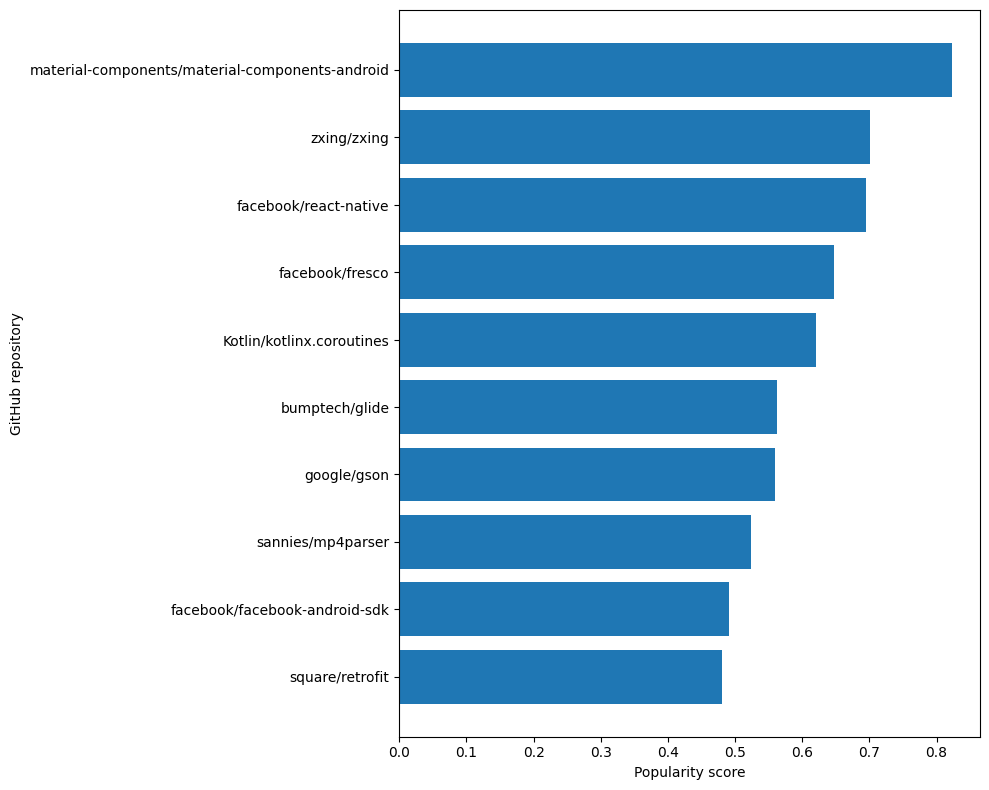

In [92]:
top_n = 10
plot_df = repo_enriched.sort_values('popularity_score', ascending=False).head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(plot_df['github_repo_full_name'][::-1], plot_df['popularity_score'][::-1])
plt.xlabel('Popularity score')
plt.ylabel('GitHub repository')
# plt.title(f'Top {top_n} repositories by popularity score')
plt.tight_layout()
save_current_figure('top_repositories_by_popularity_score.png')
plt.show()



Saved figure: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/top_repositories_by_activity_score.png


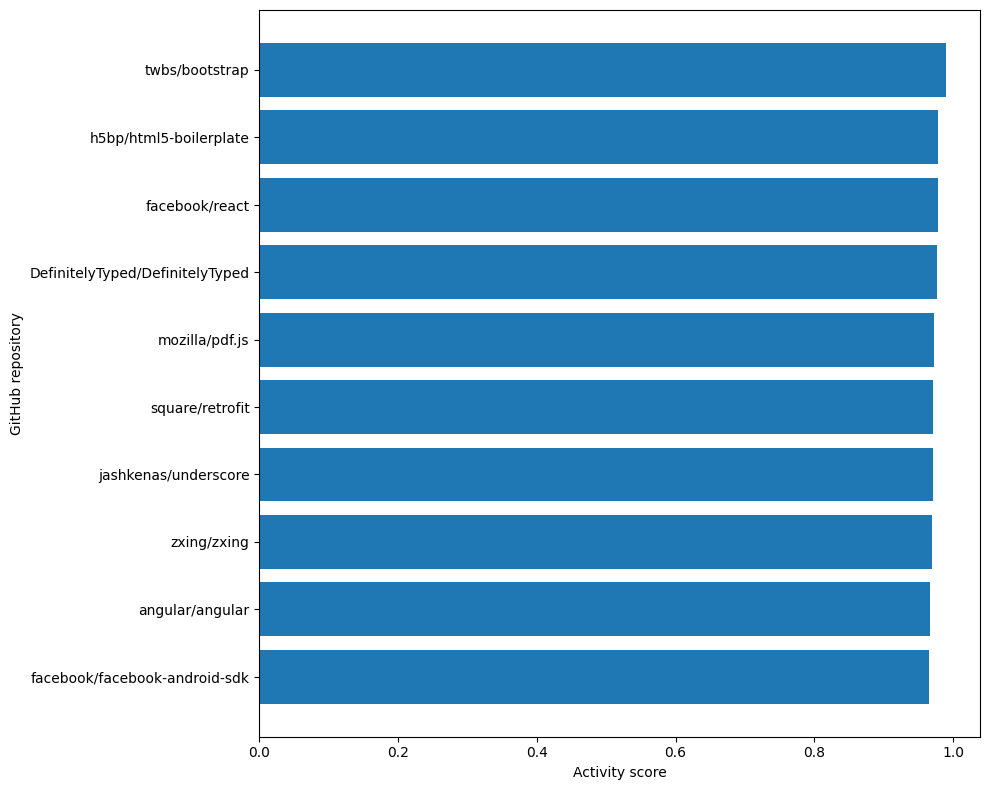

In [93]:
plot_df = repo_enriched.sort_values('activity_score', ascending=False).head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(plot_df['github_repo_full_name'][::-1], plot_df['activity_score'][::-1])
plt.xlabel('Activity score')
plt.ylabel('GitHub repository')
# plt.title(f'Top {top_n} repositories by repository activity score')
plt.tight_layout()
save_current_figure('top_repositories_by_activity_score.png')
plt.show()



Saved figure: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/top_repositories_by_fragility_score.png


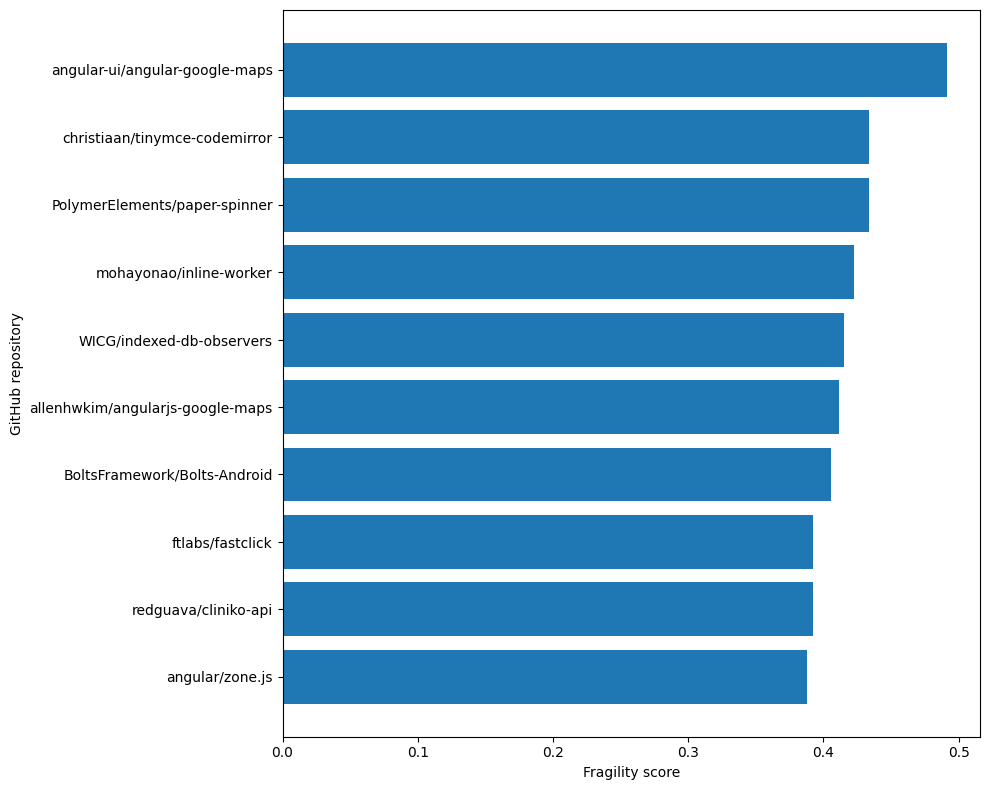

In [94]:
plot_df = repo_enriched.sort_values('fragility_score', ascending=False).head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(plot_df['github_repo_full_name'][::-1], plot_df['fragility_score'][::-1])
plt.xlabel('Fragility score')
plt.ylabel('GitHub repository')
# plt.title(f'Top {top_n} repositories by fragility score')
plt.tight_layout()
save_current_figure('top_repositories_by_fragility_score.png')
plt.show()



Saved figure: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/repository_count_by_fragility_level.png


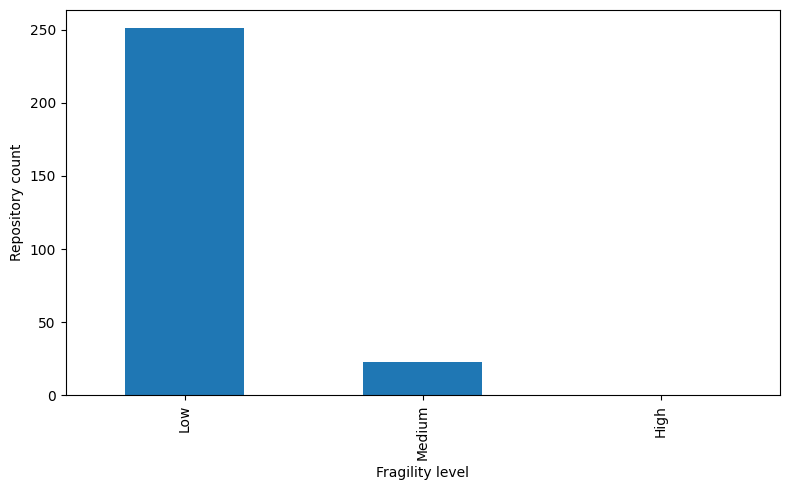

In [95]:
plt.figure(figsize=(8, 5))
repo_enriched['fragility_level'].value_counts(dropna=False).sort_index().plot(kind='bar')
plt.xlabel('Fragility level')
plt.ylabel('Repository count')
# plt.title('Repository count by fragility level')
plt.tight_layout()
save_current_figure('repository_count_by_fragility_level.png')
plt.show()



In [96]:
repo_enriched['fragility_level'].value_counts(dropna=False).sort_index()

fragility_level
Low       251
Medium     23
High        0
Name: count, dtype: int64

Saved figure: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/popularity_vs_fragility.png


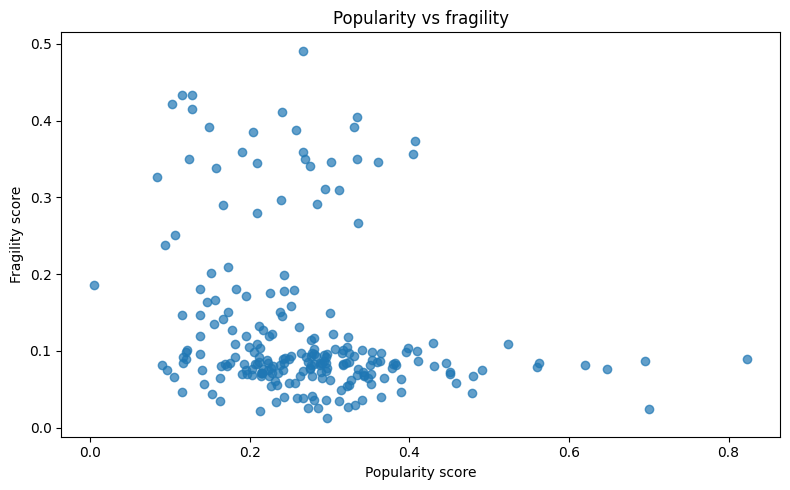

In [97]:
plt.figure(figsize=(8, 5))
plt.scatter(repo_enriched['popularity_score'], repo_enriched['fragility_score'], alpha=0.7)
plt.xlabel('Popularity score')
plt.ylabel('Fragility score')
plt.title('Popularity vs fragility')
plt.tight_layout()
save_current_figure('popularity_vs_fragility.png')
plt.show()



Saved figure: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/popularity_vs_fragility.png


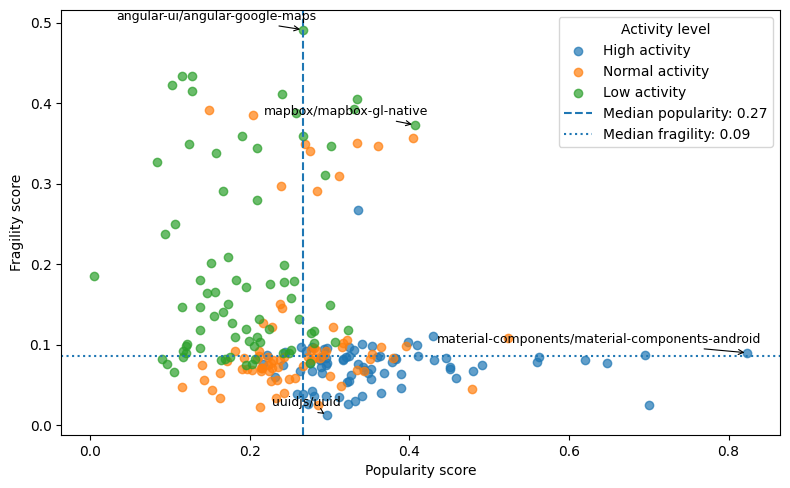

In [98]:
# Popularity vs fragility, colored by activity level

plot_df = repo_enriched[
    ['github_repo_full_name', 'popularity_score', 'fragility_score', 'activity_score']
].dropna().copy()

# Split activity into 3 categories using tertiles.
plot_df['activity_category'] = pd.qcut(
    plot_df['activity_score'],
    q=3,
    labels=['Low activity', 'Normal activity', 'High activity'],
    duplicates='drop'
)

popularity_median = plot_df['popularity_score'].median()
fragility_median = plot_df['fragility_score'].median()

plt.figure(figsize=(8, 5))

for category in plot_df['activity_category'].dropna().unique():
    subset = plot_df[plot_df['activity_category'] == category]
    plt.scatter(
        subset['popularity_score'],
        subset['fragility_score'],
        alpha=0.7,
        label=category
    )

plt.axvline(
    popularity_median,
    linestyle='--',
    linewidth=1.5,
    label=f'Median popularity: {popularity_median:.2f}'
)

plt.axhline(
    fragility_median,
    linestyle=':',
    linewidth=1.5,
    label=f'Median fragility: {fragility_median:.2f}'
)

# -----------------------------
# Select points to annotate
# -----------------------------

low_activity = plot_df[plot_df['activity_category'] == 'Low activity'].copy()
high_activity = plot_df[plot_df['activity_category'] == 'High activity'].copy()

points_to_annotate = []

# 1. Low activity with highest popularity + fragility
if not low_activity.empty:
    idx = (low_activity['popularity_score'] + low_activity['fragility_score']).idxmax()
    points_to_annotate.append(idx)

# 2. Low activity with highest fragility
if not low_activity.empty:
    idx = low_activity['fragility_score'].idxmax()
    points_to_annotate.append(idx)

# 3. High activity with highest popularity - fragility
if not high_activity.empty:
    idx = (high_activity['popularity_score'] - high_activity['fragility_score']).idxmax()
    points_to_annotate.append(idx)

# 4. Lowest fragility overall
idx = plot_df['fragility_score'].idxmin()
points_to_annotate.append(idx)

# Remove duplicates while keeping order
points_to_annotate = list(dict.fromkeys(points_to_annotate))

# -----------------------------
# Add annotations
# -----------------------------

for idx in points_to_annotate:
    row = plot_df.loc[idx]

    plt.annotate(
        row['github_repo_full_name'],
        xy=(row['popularity_score'], row['fragility_score']),
        xytext=(10, 5),
        ha='right',
        va='bottom',        
        textcoords='offset points',
        fontsize=9,
        arrowprops=dict(
            arrowstyle='->',
            linewidth=0.8
        )
    )

plt.xlabel('Popularity score')
plt.ylabel('Fragility score')
# plt.title('Popularity vs fragility by activity level')
plt.legend(title='Activity level')
plt.tight_layout()

save_current_figure('popularity_vs_fragility.png')
plt.show()

Saved figure: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/popularity_vs_activity_fragility.png


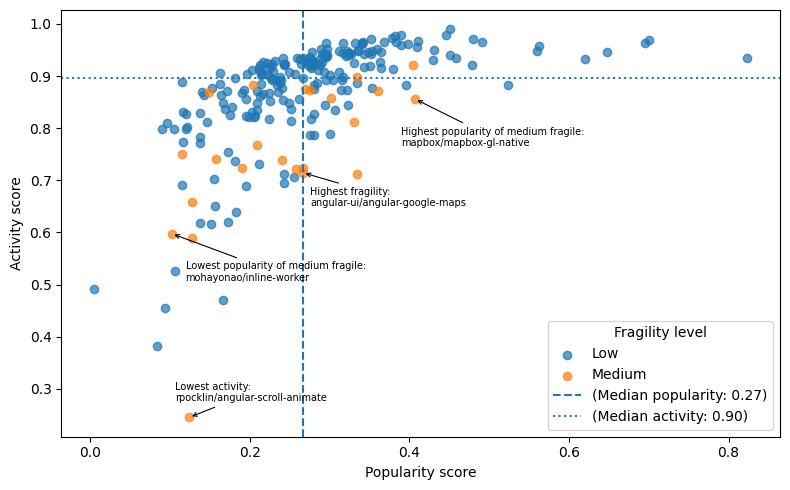

In [152]:
# Popularity vs activity, colored by fragility level

plot_df = repo_enriched[
    ['github_repo_full_name', 'popularity_score', 'fragility_score', 'activity_score', 'fragility_level']
].dropna().copy()

popularity_median = plot_df['popularity_score'].median()
activity_median = plot_df['activity_score'].median()

plt.figure(figsize=(8, 5))

for category in plot_df['fragility_level'].dropna().unique():
    subset = plot_df[plot_df['fragility_level'] == category]
    plt.scatter(
        subset['popularity_score'],
        subset['activity_score'],
        alpha=0.7,
        label=category
    )

plt.axvline(
    popularity_median,
    linestyle='--',
    linewidth=1.5,
    label=f'(Median popularity: {popularity_median:.2f})'
)

plt.axhline(
    activity_median,
    linestyle=':',
    linewidth=1.5,
    label=f'(Median activity: {activity_median:.2f})'
)

# -----------------------------
# Select points to annotate
# -----------------------------

low_fragility = plot_df[plot_df['fragility_level'] == 'Low'].copy()
high_fragility = plot_df[plot_df['fragility_level'] == 'Medium'].copy()

points_to_annotate = []

# 1. Low fragility with highest popularity + activity
idx = (low_fragility['popularity_score'] + low_fragility['activity_score']).idxmax()
label = 'Highest popularity'
anchor_x = 'right'
anchor_y = 'top'
offset_x = 5
offset_y = -20
# points_to_annotate.append((idx, label, anchor_x, anchor_y, offset_x, offset_y))

# 2. Low fragility with highest activity
idx = low_fragility['activity_score'].idxmax()
label = 'Highest activity'
anchor_x = 'left'
anchor_y = 'bottom'
offset_x = 20
offset_y = -3
# points_to_annotate.append((idx, label, anchor_x, anchor_y, offset_x, offset_y))

# 3. Low fragility with lowest popularity
idx = high_fragility['popularity_score'].idxmin()
label = 'Lowest popularity of medium fragile'
anchor_x = 'left'
anchor_y = 'top'
offset_x = 10
offset_y = -20
points_to_annotate.append((idx, label, anchor_x, anchor_y, offset_x, offset_y))

# 3.1. Low fragility with highest popularity
idx = high_fragility['popularity_score'].idxmax()
label = 'Highest popularity of medium fragile'
anchor_x = 'left'
anchor_y = 'top'
offset_x = -10
offset_y = -20
points_to_annotate.append((idx, label, anchor_x, anchor_y, offset_x, offset_y))

# 4. Lowest fragility overall
idx = plot_df['fragility_score'].idxmin()
label = 'Lowest fragility'
anchor_x = 'right'
anchor_y = 'bottom'
offset_x = -20
offset_y = 10
# points_to_annotate.append((idx, label, anchor_x, anchor_y, offset_x, offset_y))

# 5. Highest fragility overall
idx = plot_df['fragility_score'].idxmax()
label = 'Highest fragility'
anchor_x = 'left'
anchor_y = 'top'
offset_x = 5
offset_y = -10
points_to_annotate.append((idx, label, anchor_x, anchor_y, offset_x, offset_y))

# 6. Lowest activity overall
idx = plot_df['activity_score'].idxmin()
label = 'Lowest activity'
anchor_x = 'left'
anchor_y = 'bottom'
offset_x = -10
offset_y = 10
points_to_annotate.append((idx, label, anchor_x, anchor_y, offset_x, offset_y))

# # Remove duplicates while keeping order
# points_to_annotate = list(dict.fromkeys(points_to_annotate))

# -----------------------------
# Add annotations
# -----------------------------

for point in points_to_annotate:
    row = plot_df.loc[point[0]]

    plt.annotate(
        point[1] + ':\n' + row['github_repo_full_name'],
        xy=(row['popularity_score'], row['activity_score']),
        xytext=(point[4], point[5]),
        ha=point[2],
        va=point[3],        
        textcoords='offset points',
        fontsize=7,
        arrowprops=dict(
            arrowstyle='->',
            linewidth=0.8
        )
    )

plt.xlabel('Popularity score')
plt.ylabel('Activity score')
# plt.title('Popularity vs fragility by activity level')
plt.legend(title='Fragility level')
plt.tight_layout()

save_current_figure('popularity_vs_activity_fragility.png')
plt.show()

## 14. Optional: inspect repos that still need attention

Useful checks:

- Repos that were not found on GitHub.
- Repos with high usage in APKs but high fragility.
- Repos with missing license metadata.


In [67]:
not_found = repo_enriched[repo_enriched['github_found'] == 0].copy()
not_found[['github_repo_full_name', 'library_occurrences', 'apk_count', 'github_error_status', 'github_error_message']].head(50)


,github_repo_full_name,library_occurrences,apk_count,github_error_status,github_error_message
126,tradingview/charting_library,3,2,404.0,Not Found
151,driftyco/ionic-platform-web-client,2,1,404.0,Not Found
160,EqualsGroup/em-transactions-api,1,1,404.0,Not Found
161,EqualsGroup/equals-money-apps,1,1,404.0,Not Found
168,NorwegianBlockExchange/card-service,1,1,404.0,Not Found
169,NorwegianBlockExchange/dev-support,1,1,404.0,Not Found
170,OrangeGangsters/SwipyRefreshLayoutblob,1,1,404.0,Not Found
194,cordova-sms/cordova-sms-plugin.,1,1,404.0,Not Found
195,crypto-browserify/crypto-browserify,1,1,404.0,Not Found
216,jhermsmeier/emitter.js,1,1,404.0,Not Found


In [68]:
high_usage_high_fragility = repo_enriched[
    (repo_enriched['library_occurrences'] >= repo_enriched['library_occurrences'].quantile(0.75)) &
    (repo_enriched['fragility_score'] >= repo_enriched['fragility_score'].quantile(0.75))
].sort_values(['fragility_score', 'library_occurrences'], ascending=False)

high_usage_high_fragility[[
    'github_repo_full_name', 'library_occurrences', 'apk_count',
    'stars_count', 'days_since_push', 'is_archived', 'license_key',
    'fragility_score', 'fragility_level'
]].head(50)


,github_repo_full_name,library_occurrences,apk_count,stars_count,days_since_push,is_archived,license_key,fragility_score,fragility_level
66,mohayonao/inline-worker,22,22,67.0,2752.0,True,mit,0.422282,Medium
30,BoltsFramework/Bolts-Android,168,167,4009.0,2609.0,True,mit,0.405319,Medium
22,mapbox/mapbox-gl-native,316,316,4450.0,1011.0,True,other,0.372948,Medium
56,bugsnag/bugsnag-react-native,32,15,371.0,2063.0,True,mit,0.359076,Medium
38,google/flexbox-layout,105,105,18339.0,741.0,True,apache-2.0,0.346514,Medium
67,apache/cordova-plugin-whitelist,21,21,442.0,1661.0,True,apache-2.0,0.344517,Medium
63,chrisbanes/snapper,23,23,463.0,1270.0,True,apache-2.0,0.337785,Medium
68,vinc3m1/RoundedImageView,21,11,6411.0,1191.0,True,other,0.310775,Low
53,microsoft/react-native-code-push,37,33,9137.0,347.0,True,other,0.309678,Low
32,aws/aws-amplify,167,164,NaN,NaN,NaN,NaN,0.250000,Low


In [69]:
missing_license = repo_enriched[
    (repo_enriched['github_found'] == 1) &
    (repo_enriched['license_key'].isna())
].sort_values('library_occurrences', ascending=False)

missing_license[[
    'github_repo_full_name', 'library_occurrences', 'apk_count',
    'stars_count', 'forks_count', 'license_key', 'fragility_score'
]].head(50)


,github_repo_full_name,library_occurrences,apk_count,stars_count,forks_count,license_key,fragility_score
28,ionic-team/capacitor-plugins,202,23,660.0,675.0,NaN,0.122011
47,capawesome-team/capacitor-plugins,58,23,449.0,99.0,NaN,0.126573
59,EddyVerbruggen/Calendar-PhoneGap-Plugin,26,22,772.0,401.0,NaN,0.175159
83,PolymerElements/paper-spinner,8,4,40.0,18.0,NaN,0.433614
86,naman14/TAndroidLame,6,6,273.0,74.0,NaN,0.141077
110,mattdesl/lwjgl-basics,4,4,1892.0,181.0,NaN,0.198430
111,OnsenUI/OnsenUI,4,2,8866.0,1005.0,NaN,0.095686
130,SimpleMobileTools/General-Discussion,3,1,162.0,28.0,NaN,0.163570
144,warpdesign/deferred-js,2,2,49.0,5.0,NaN,0.327200
226,lrsjng/pagemap,1,1,1286.0,62.0,NaN,0.119275


## 16. Final corpus questions — APK use of medium-fragility open source libraries

This final section joins the two analysis paths in this notebook:

1. **APK/library usage evidence** from `dataset_700.csv`, especially `pkg_name`, `repo_url`, `cited`, `origin`, and `classes_matched`.
2. **GitHub-based library fragility** from the enriched repository table, especially `fragility_score` and `fragility_level`.

The goal is to answer:

- Which APKs use open source libraries with **Medium** fragility?
- How intense is that use inside each APK?
- Which APKs use **Medium** fragility libraries but have `cited = 0`?
- How intense is the uncited use?

For intensity, this notebook uses:

\[
\text{intensity pct} = \frac{\text{classes\_matched for selected rows}}{\text{total classes\_matched for the APK}} \times 100
\]

A higher percentage means a larger share of that APK's detected open-source class usage comes from the selected medium-fragility libraries.

In [70]:
# -------------------------------------------------------------------
# Join row-level APK/library usage with repo-level GitHub fragility
# and app metadata from tagged_apps.csv
# -------------------------------------------------------------------

required_objects = ['df', 'repo_enriched', 'OUTPUT_DIR', 'TAGGED_APPS_FILE']
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        'Please run the previous notebook cells first. Missing objects: '
        + ', '.join(missing_objects)
    )

usage_df = df.copy()

if 'classes_matched' not in usage_df.columns:
    raise ValueError('Expected column not found: classes_matched')

usage_df['classes_matched_numeric'] = pd.to_numeric(
    usage_df['classes_matched'], errors='coerce'
).fillna(0)

# Total detected open-source class matches per APK.
apk_totals = (
    usage_df.groupby('pkg_name', dropna=False)['classes_matched_numeric']
    .sum()
    .reset_index(name='apk_total_classes_matched')
)

# App metadata: pkg_name is the identifier, app_name is the human-readable title.
# The file is expected at ../analysis_datasets/tagged_apps.csv.
if TAGGED_APPS_FILE.exists():
    tagged_apps = pd.read_csv(TAGGED_APPS_FILE)
    required_tagged_cols = ['pkg_name', 'app_name', 'downloads', 'category']
    missing_tagged_cols = [c for c in required_tagged_cols if c not in tagged_apps.columns]
    if missing_tagged_cols:
        raise ValueError(f'tagged_apps.csv is missing required columns: {missing_tagged_cols}')

    tagged_apps_lookup = (
        tagged_apps[required_tagged_cols]
        .drop_duplicates(subset=['pkg_name'])
        .copy()
    )
else:
    print(f'Warning: tagged_apps.csv not found at {TAGGED_APPS_FILE}. Falling back to pkg_name labels.')
    tagged_apps_lookup = pd.DataFrame({
        'pkg_name': usage_df['pkg_name'].drop_duplicates(),
        'app_name': usage_df['pkg_name'].drop_duplicates(),
        'downloads': np.nan,
        'category': 'Unknown',
    })

fragility_columns = [
    'github_repo_full_name',
    'fragility_score',
    'fragility_level',
    'popularity_score',
    'activity_score',
    'stars_count',
    'forks_count',
    'open_issues_count',
    'days_since_push',
    'days_since_update',
    'is_archived',
    'is_disabled',
    'license_key',
]
fragility_columns = [c for c in fragility_columns if c in repo_enriched.columns]

repo_fragility_lookup = (
    repo_enriched[fragility_columns]
    .drop_duplicates(subset=['github_repo_full_name'])
)

usage_fragility_df = usage_df.merge(
    repo_fragility_lookup,
    on='github_repo_full_name',
    how='left'
).merge(
    apk_totals,
    on='pkg_name',
    how='left'
).merge(
    tagged_apps_lookup,
    on='pkg_name',
    how='left'
)

usage_fragility_df['app_name'] = usage_fragility_df['app_name'].fillna(usage_fragility_df['pkg_name'])
usage_fragility_df['category'] = usage_fragility_df['category'].fillna('Unknown')
usage_fragility_df['app_label'] = np.where(
    usage_fragility_df['app_name'].astype(str).str.strip().ne(''),
    usage_fragility_df['app_name'].astype(str),
    usage_fragility_df['pkg_name'].astype(str),
)

usage_fragility_df['row_intensity_pct_of_apk'] = np.where(
    usage_fragility_df['apk_total_classes_matched'] > 0,
    usage_fragility_df['classes_matched_numeric'] / usage_fragility_df['apk_total_classes_matched'] * 100,
    np.nan,
)

medium_fragility_rows = usage_fragility_df[
    usage_fragility_df['fragility_level'].astype(str).str.lower().eq('medium')
].copy()

medium_fragility_uncited_rows = medium_fragility_rows[
    medium_fragility_rows['cited'].fillna(0).astype(int).eq(0)
].copy()

print('All dataset rows:', len(usage_fragility_df))
print('Rows joined to a GitHub fragility level:', usage_fragility_df['fragility_level'].notna().sum())
print('Rows joined to app metadata:', usage_fragility_df['app_name'].notna().sum())
print('Medium-fragility usage rows:', len(medium_fragility_rows))
print('Medium-fragility uncited rows:', len(medium_fragility_uncited_rows))

medium_fragility_rows.head(10)


All dataset rows: 108234
Rows joined to a GitHub fragility level: 106368
Rows joined to app metadata: 108234
Medium-fragility usage rows: 739
Medium-fragility uncited rows: 346


,pkg_name,repo_host,repo_path,repo_url,cited,origin,libarary_key,library_name,smali_prefix,fingerprint_types,classes_matched,sample_class,sample_class_file,library_key,origin_fingerprint,origin_license_exposure,github_repo_full_name,classes_matched_numeric,fragility_score,fragility_level,popularity_score,activity_score,stars_count,forks_count,open_issues_count,days_since_push,days_since_update,is_archived,is_disabled,license_key,apk_total_classes_matched,app_name,downloads,category,app_label,row_intensity_pct_of_apk
0,ai.asleep.sleepstar,github.com,BoltsFramework/Bolts-Android,https://github.com/BoltsFramework/Bolts-Android,1,fingerprints,BoltsFramework/Bolts-Android,Bolts-Android,Lbolts/,java_package,36.0,Lbolts/AggregateException;,data/decoded/ai.asleep.sleepstar/smali_classes...,BoltsFramework/Bolts-Android,1,0,BoltsFramework/Bolts-Android,36.0,0.405319,Medium,0.333960,0.712290,4009.0,523.0,27.0,2609.0,1.0,True,False,mit,68959.0,"Sleep AI: Track, Sounds, Alarm",5K+,HEALTH_AND_FITNESS,"Sleep AI: Track, Sounds, Alarm",0.052205
559,ai.nodepay.mobileapp,github.com,mapbox/mapbox-gl-native,https://github.com/mapbox/mapbox-gl-native,0,fingerprints,mapbox/mapbox-gl-native,mapbox-gl-native,Landroid/app/,java_package,2.0,Landroid/app/AppComponentFactory;,data/decoded/ai.nodepay.mobileapp/smali/androi...,mapbox/mapbox-gl-native,1,0,mapbox/mapbox-gl-native,2.0,0.372948,Medium,0.406899,0.856081,4450.0,1321.0,312.0,1011.0,3.0,True,False,other,831.0,Nodepay,1M+,FINANCE,Nodepay,0.240674
561,ai.roundtrip.easyroutes,github.com,BoltsFramework/Bolts-Android,https://github.com/BoltsFramework/Bolts-Android,1,fingerprints,BoltsFramework/Bolts-Android,Bolts-Android,Lbolts/,java_package,36.0,Lbolts/AggregateException;,data/decoded/ai.roundtrip.easyroutes/smali/bol...,BoltsFramework/Bolts-Android,1,0,BoltsFramework/Bolts-Android,36.0,0.405319,Medium,0.333960,0.712290,4009.0,523.0,27.0,2609.0,1.0,True,False,mit,35569.0,EasyRoutes Delivery Driver,10K+,MAPS_AND_NAVIGATION,EasyRoutes Delivery Driver,0.101212
848,ai.roundtrip.easyroutes,github.com,mapbox/mapbox-gl-native,https://github.com/mapbox/mapbox-gl-native,1,fingerprints,mapbox/mapbox-gl-native,mapbox-gl-native,Landroid/app/,java_package,1.0,Landroid/app/servertransaction/ClientTransaction;,data/decoded/ai.roundtrip.easyroutes/smali/and...,mapbox/mapbox-gl-native,1,0,mapbox/mapbox-gl-native,1.0,0.372948,Medium,0.406899,0.856081,4450.0,1321.0,312.0,1011.0,3.0,True,False,other,35569.0,EasyRoutes Delivery Driver,10K+,MAPS_AND_NAVIGATION,EasyRoutes Delivery Driver,0.002811
922,ai.startalk.jp,github.com,mapbox/mapbox-gl-native,https://github.com/mapbox/mapbox-gl-native,1,fingerprints,mapbox/mapbox-gl-native,mapbox-gl-native,Landroid/app/,java_package,2.0,Landroid/app/AppComponentFactory;,data/decoded/ai.startalk.jp/smali/android/app/...,mapbox/mapbox-gl-native,1,0,mapbox/mapbox-gl-native,2.0,0.372948,Medium,0.406899,0.856081,4450.0,1321.0,312.0,1011.0,3.0,True,False,other,3998.0,StarTalk ファン,50+,COMMUNICATION,StarTalk ファン,0.050025
934,ao.gov.minfin.app,github.com,mapbox/mapbox-gl-native,https://github.com/mapbox/mapbox-gl-native,0,fingerprints,mapbox/mapbox-gl-native,mapbox-gl-native,Landroid/app/,java_package,12.0,Landroid/app/AppComponentFactory;,data/decoded/ao.gov.minfin.app/smali/android/a...,mapbox/mapbox-gl-native,1,0,mapbox/mapbox-gl-native,12.0,0.372948,Medium,0.406899,0.856081,4450.0,1321.0,312.0,1011.0,3.0,True,False,other,1538.0,App Minfin,100K+,FINANCE,App Minfin,0.780234
1126,app.bsms.bluesky_communicator,github.com,mapbox/mapbox-gl-native,https://github.com/mapbox/mapbox-gl-native,0,fingerprints,mapbox/mapbox-gl-native,mapbox-gl-native,Landroid/app/,java_package,2.0,Landroid/app/AppComponentFactory;,data/decoded/app.bsms.bluesky_communicator/sma...,mapbox/mapbox-gl-native,1,0,mapbox/mapbox-gl-native,2.0,0.372948,Medium,0.406899,0.856081,4450.0,1321.0,312.0,1011.0,3.0,True,False,other,22308.0,BlueSky Communicator,500+,COMMUNICATION,BlueSky Communicator,0.008965
1156,app.fitlab.jaquelinela

### 16.1 APKs that use medium-fragility libraries

The table below aggregates each APK's use of medium-fragility repositories. The main intensity field is `medium_fragility_intensity_pct_of_apk`, which shows what percentage of the APK's total detected `classes_matched` comes from medium-fragility libraries.

In [71]:
def join_unique_values(values, max_items=12):
    cleaned = [str(v) for v in values.dropna().unique() if str(v).strip()]
    cleaned = sorted(cleaned)
    if len(cleaned) > max_items:
        return ', '.join(cleaned[:max_items]) + f', ... (+{len(cleaned) - max_items} more)'
    return ', '.join(cleaned)


def aggregate_apk_fragility_usage(rows: pd.DataFrame, prefix: str) -> pd.DataFrame:
    base_columns = [
        'pkg_name',
        'app_name',
        'app_label',
        'downloads',
        'category',
        f'{prefix}_rows',
        f'{prefix}_unique_repos',
        f'{prefix}_classes_matched',
        'apk_total_classes_matched',
        f'{prefix}_intensity_pct_of_apk',
    ]
    if rows.empty:
        return pd.DataFrame(columns=base_columns)

    agg = (
        rows.groupby('pkg_name', dropna=False)
        .agg(
            app_name=('app_name', 'first'),
            app_label=('app_label', 'first'),
            downloads=('downloads', 'first'),
            category=('category', 'first'),
            **{
                f'{prefix}_rows': ('pkg_name', 'size'),
                f'{prefix}_unique_repos': ('github_repo_full_name', 'nunique'),
                f'{prefix}_classes_matched': ('classes_matched_numeric', 'sum'),
                'apk_total_classes_matched': ('apk_total_classes_matched', 'first'),
                f'{prefix}_mean_fragility_score': ('fragility_score', 'mean'),
                f'{prefix}_max_fragility_score': ('fragility_score', 'max'),
                f'{prefix}_repos': ('github_repo_full_name', join_unique_values),
                f'{prefix}_library_names': ('library_name', join_unique_values) if 'library_name' in rows.columns else ('github_repo_full_name', join_unique_values),
            }
        )
        .reset_index()
    )

    agg[f'{prefix}_intensity_pct_of_apk'] = np.where(
        agg['apk_total_classes_matched'] > 0,
        agg[f'{prefix}_classes_matched'] / agg['apk_total_classes_matched'] * 100,
        np.nan,
    )

    return agg.sort_values(
        [f'{prefix}_intensity_pct_of_apk', f'{prefix}_classes_matched', f'{prefix}_unique_repos'],
        ascending=False,
    )

medium_apk_usage = aggregate_apk_fragility_usage(
    medium_fragility_rows,
    prefix='medium_fragility'
)

print('APKs using at least one medium-fragility library:', medium_apk_usage['pkg_name'].nunique())
medium_apk_usage.head(30)


APKs using at least one medium-fragility library: 516


,pkg_name,app_name,app_label,downloads,category,medium_fragility_rows,medium_fragility_unique_repos,medium_fragility_classes_matched,apk_total_classes_matched,medium_fragility_mean_fragility_score,medium_fragility_max_fragility_score,medium_fragility_repos,medium_fragility_library_names,medium_fragility_intensity_pct_of_apk
320,com.q2e.cabrillocreditunion5080.mobile.production,Cabrillo Credit Union,Cabrillo Credit Union,10K+,FINANCE,2,1,644.0,6034.0,0.359076,0.359076,bugsnag/bugsnag-react-native,bugsnag-react-native,10.672854
345,com.softek.ofxclmobile.ukfcu,UK Credit Union,UK Credit Union,10K+,FINANCE,2,1,644.0,6886.0,0.359076,0.359076,bugsnag/bugsnag-react-native,bugsnag-react-native,9.352309
90,com.brightstarcreditunion5196.production,BrightStar CU Mobile,BrightStar CU Mobile,10K+,FINANCE,2,1,324.0,5209.0,0.359076,0.359076,bugsnag/bugsnag-react-native,bugsnag-react-native,6.220004
41,com.AppleBank.AppleBankOnline,Apple Bank Mobile Banking,Apple Bank Mobile Banking,100K+,FINANCE,3,2,650.0,12607.0,0.363700,0.372948,"bugsnag/bugsnag-react-native, mapbox/mapbox-gl...","bugsnag-react-native, mapbox-gl-native",5.155866
426,de.appack.project.wir_pflegen,in.kontakt,in.kontakt,1K+,COMMUNICATION,3,2,828.0,16188.0,0.363700,0.372948,"bugsnag/bugsnag-react-native, mapbox/mapbox-gl...","bugsnag-react-native, mapbox-gl-native",5.114900
69,com.arketa.bodyrestoration,BodyRestoration,BodyRestoration,5+,HEALTH_AND_FITNESS,3,2,541.0,15571.0,0.363700,0.372948,"bugsnag/bugsnag-react-native, mapbox/mapbox-gl...","bugsnag-react-native, mapbox-gl-native",3.474408
363,com.tickz,Tickz. App broker for trading,Tickz. App broker for trading,1M+,FINANCE,3,2,908.0,27265.0,0.363700,0.372948,"bugsnag/bugsnag-react-native, mapbox/mapbox-gl...","bugsnag-react-native, mapbox-gl-native",3.330277
288,com.omada.prevent,Omada,Omada,500K+,MEDICAL,3,2,719.0,22472.0,0.354889,0.359076,"bugsnag/bugsnag-react-native, google/flexbox-l...","bugsnag-react-native, flexbox-layout",3.199537
39,co.vantek.dma.cucchiara.prod,Cucchiara DMA,Cucchiara DMA,100+,FINANCE,3,2,3.0,97.0,0.403915,0.433614,"PolymerElements/paper-spinner, apache/cordova-...","PolymerElements/paper-spinner, cordova-plugin-...",3.092784
319,com.pushpress.losdelaislacrossfit,Los de la Isla CrossFit,Los de la Isla CrossFit,10+,HEALTH_AND_FITNESS,3,2,145.0,5040.0,0.363700,0.372948,"bugsnag/bugsnag-react-native, mapbox/mapbox-gl...","bugsnag-react-native, mapbox-gl-native",2.876984


### 16.2 APKs that use medium-fragility libraries but did not cite them

This table applies the same intensity logic, but only for medium-fragility rows where `cited = 0`. Two intensity percentages are useful:

- `medium_fragility_uncited_intensity_pct_of_apk`: uncited medium-fragility classes as a share of all detected open-source class matches in the APK.
- `uncited_share_of_medium_fragility_classes_pct`: among the APK's medium-fragility class matches, the percentage that came from uncited rows.

In [72]:
medium_uncited_apk_usage = aggregate_apk_fragility_usage(
    medium_fragility_uncited_rows,
    prefix='medium_fragility_uncited'
)

# Add context from all medium-fragility usage for the same APK.
context_cols = [
    'pkg_name',
    'medium_fragility_rows',
    'medium_fragility_unique_repos',
    'medium_fragility_classes_matched',
    'medium_fragility_intensity_pct_of_apk',
]
context_cols = [c for c in context_cols if c in medium_apk_usage.columns]

medium_uncited_apk_usage = medium_uncited_apk_usage.merge(
    medium_apk_usage[context_cols],
    on='pkg_name',
    how='left'
)

medium_uncited_apk_usage['uncited_share_of_medium_fragility_classes_pct'] = np.where(
    medium_uncited_apk_usage['medium_fragility_classes_matched'] > 0,
    medium_uncited_apk_usage['medium_fragility_uncited_classes_matched'] /
    medium_uncited_apk_usage['medium_fragility_classes_matched'] * 100,
    np.nan,
)

medium_uncited_apk_usage = medium_uncited_apk_usage.sort_values(
    [
        'medium_fragility_uncited_intensity_pct_of_apk',
        'uncited_share_of_medium_fragility_classes_pct',
        'medium_fragility_uncited_classes_matched',
    ],
    ascending=False,
)

print('APKs using at least one uncited medium-fragility library:', medium_uncited_apk_usage['pkg_name'].nunique())
medium_uncited_apk_usage.head(30)


APKs using at least one uncited medium-fragility library: 268


,pkg_name,app_name,app_label,downloads,category,medium_fragility_uncited_rows,medium_fragility_uncited_unique_repos,medium_fragility_uncited_classes_matched,apk_total_classes_matched,medium_fragility_uncited_mean_fragility_score,medium_fragility_uncited_max_fragility_score,medium_fragility_uncited_repos,medium_fragility_uncited_library_names,medium_fragility_uncited_intensity_pct_of_apk,medium_fragility_rows,medium_fragility_unique_repos,medium_fragility_classes_matched,medium_fragility_intensity_pct_of_apk,uncited_share_of_medium_fragility_classes_pct
0,de.appack.project.wir_pflegen,in.kontakt,in.kontakt,1K+,COMMUNICATION,3,2,828.0,16188.0,0.363700,0.372948,"bugsnag/bugsnag-react-native, mapbox/mapbox-gl...","bugsnag-react-native, mapbox-gl-native",5.114900,3,2,828.0,5.114900,100.0
1,com.tickz,Tickz. App broker for trading,Tickz. App broker for trading,1M+,FINANCE,3,2,908.0,27265.0,0.363700,0.372948,"bugsnag/bugsnag-react-native, mapbox/mapbox-gl...","bugsnag-react-native, mapbox-gl-native",3.330277,3,2,908.0,3.330277,100.0
2,com.pushpress.losdelaislacrossfit,Los de la Isla CrossFit,Los de la Isla CrossFit,10+,HEALTH_AND_FITNESS,3,2,145.0,5040.0,0.363700,0.372948,"bugsnag/bugsnag-react-native, mapbox/mapbox-gl...","bugsnag-react-native, mapbox-gl-native",2.876984,3,2,145.0,2.876984,100.0
3,com.crypto.exchange,Crypto.com Exchange,Crypto.com Exchange,1M+,FINANCE,3,2,377.0,17147.0,0.363700,0.372948,"bugsnag/bugsnag-react-native, mapbox/mapbox-gl...","bugsnag-react-native, mapbox-gl-native",2.198635,3,2,377.0,2.198635,100.0
4,com.geeckoltd.apps.tfixspot,TfixSpot,TfixSpot,500+,MAPS_AND_NAVIGATION,1,1,12.0,594.0,0.372948,0.372948,mapbox/mapbox-gl-native,mapbox-gl-native,2.020202,1,1,12.0,2.020202,100.0
5,com.certacure.ifh.application,Institue For Family Health,Institue For Family Health,100+,HEALTH_AND_FITNESS,1,1,2.0,139.0,0.372948,0.372948,mapbox/mapbox-gl-native,mapbox-gl-native,1.438849,1,1,2.0,1.438849,100.0
6,ao.gov.minfin.app,App Minfin,App Minfin,100K+,FINANCE,1,1,12.0,1538.0,0.372948,0.372948,mapbox/mapbox-gl-native,mapbox-gl-native,0.780234,1,1,12.0,0.780234,100.0
7,com.easy.bank,Easy Bank,Easy Bank,1K+,FINANCE,1,1,2.0,274.0,0.372948,0.372948,mapbox/mapbox-gl-native,mapbox-gl-native,0.729927,1,1,2.0,0.729927,100.0
8,capebustrain.navigator2,Cape Town Trains : Schedules,Cape Town Trains : Schedules,10K+,MAPS_AND_NAVIGATION,1,1,1.0,161.0,0.372948,0.372948,mapbox/mapbox-gl-native,mapbox-gl-native,0.621118,1,1,1.0,0.621118,100.0
9,com.ProsedurTindakanKeperawatan.wisnua,Nursing Action Procedure,Nursing Action Procedure,5K+,HEALTH_AND_FITNESS,1,1,2.0,349.0,0.372948,0.372948,mapbox/mapbox-gl-native,mapbox-gl-native,0.573066,1,1,2.0,0.573066,100.0


### 16.3 Row-level evidence for auditing

The next exports preserve the row-level evidence behind the APK summaries. Use these files to inspect exactly which libraries contributed to each APK's medium-fragility or uncited-medium-fragility intensity.

In [73]:
# -------------------------------------------------------------------
# Export APK-level summaries and row-level evidence
# -------------------------------------------------------------------

MEDIUM_APK_USAGE_OUTPUT = OUTPUT_DIR / 'dataset_700_medium_fragility_apk_usage.csv'
MEDIUM_UNCITED_APK_USAGE_OUTPUT = OUTPUT_DIR / 'dataset_700_medium_fragility_uncited_apk_usage.csv'
MEDIUM_ROW_DETAILS_OUTPUT = OUTPUT_DIR / 'dataset_700_medium_fragility_row_details.csv'
MEDIUM_UNCITED_ROW_DETAILS_OUTPUT = OUTPUT_DIR / 'dataset_700_medium_fragility_uncited_row_details.csv'

medium_apk_usage.to_csv(MEDIUM_APK_USAGE_OUTPUT, index=False)
medium_uncited_apk_usage.to_csv(MEDIUM_UNCITED_APK_USAGE_OUTPUT, index=False)
medium_fragility_rows.to_csv(MEDIUM_ROW_DETAILS_OUTPUT, index=False)
medium_fragility_uncited_rows.to_csv(MEDIUM_UNCITED_ROW_DETAILS_OUTPUT, index=False)

print('Saved:', MEDIUM_APK_USAGE_OUTPUT)
print('Saved:', MEDIUM_UNCITED_APK_USAGE_OUTPUT)
print('Saved:', MEDIUM_ROW_DETAILS_OUTPUT)
print('Saved:', MEDIUM_UNCITED_ROW_DETAILS_OUTPUT)

Saved: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/dataset_700_medium_fragility_apk_usage.csv
Saved: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/dataset_700_medium_fragility_uncited_apk_usage.csv
Saved: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/dataset_700_medium_fragility_row_details.csv
Saved: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/dataset_700_medium_fragility_uncited_row_details.csv


### 16.4 Visual summary

These charts show the APKs with the highest medium-fragility intensity and the APKs with the highest uncited medium-fragility intensity.

In [75]:
import matplotlib.colors as mcolors

def plot_category_colored_barh(
    plot_df: pd.DataFrame,
    value_col: str,
    title: str,
    xlabel: str,
    output_filename: str
):
    if plot_df.empty:
        print(f'No data available for {title}.')
        return

    plot_df = plot_df.copy()
    plot_df['category'] = plot_df['category'].fillna('Unknown').astype(str)
    plot_df['app_label'] = plot_df['app_label'].fillna(plot_df['pkg_name']).astype(str)

    categories = sorted(plot_df['category'].unique())

    # Create blue shades based on Matplotlib default blue: #1f77b4
    base_blue = '#1f77b4'
    blue_shades = [
        mcolors.to_hex(
            np.array(mcolors.to_rgb(base_blue)) * factor
            + np.array([1, 1, 1]) * (1 - factor)
        )
        for factor in np.linspace(0.35, 1.0, len(categories))
    ]

    category_color_map = {
        category: blue_shades[i]
        for i, category in enumerate(categories)
    }

    colors = plot_df['category'].map(category_color_map)

    plt.figure(figsize=(12, max(6, len(plot_df) * 0.4)))
    plt.barh(plot_df['app_label'], plot_df[value_col], color=colors)
    plt.xlabel(xlabel)
    plt.ylabel('App name')
    # plt.title(title)

    legend_handles = [
        mpatches.Patch(color=category_color_map[category], label=category)
        for category in categories
    ]

    plt.legend(
        handles=legend_handles,
        title='Category',
        loc='lower right',
        bbox_to_anchor=(0.98, 0.02),
        frameon=True
    )

    plt.tight_layout()
    save_current_figure(output_filename)
    plt.show()

Saved figure: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/top_apps_by_medium_fragility_intensity.png


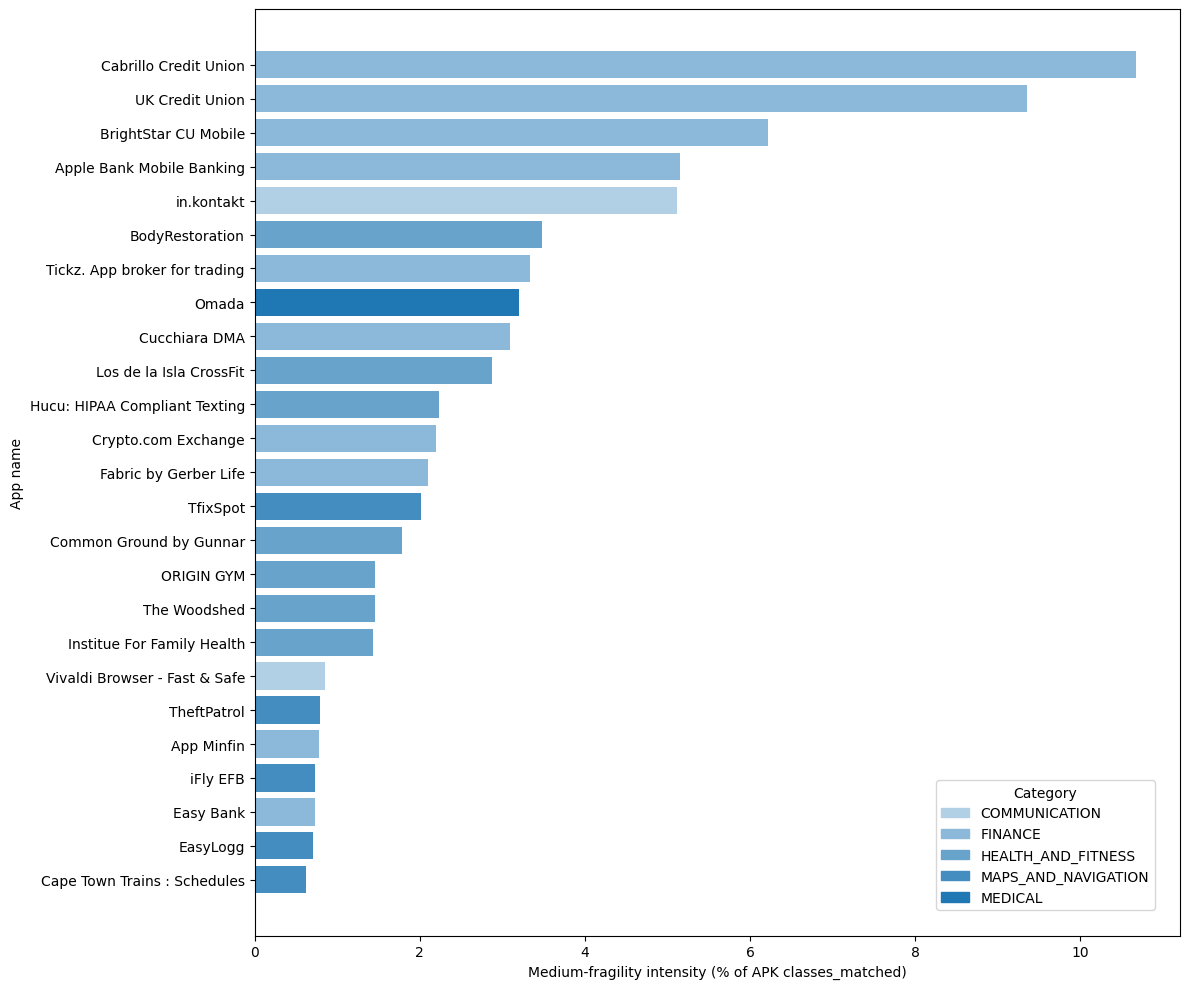

In [76]:
# Top APKs by medium-fragility intensity, using app_name labels and category colors.
plot_top_n = 25

plot_df = medium_apk_usage.head(plot_top_n).sort_values(
    'medium_fragility_intensity_pct_of_apk', ascending=True
)

plot_category_colored_barh(
    plot_df=plot_df,
    value_col='medium_fragility_intensity_pct_of_apk',
    title=f'Top {min(plot_top_n, len(plot_df))} apps by medium-fragility library usage intensity',
    xlabel='Medium-fragility intensity (% of APK classes_matched)',
    output_filename='top_apps_by_medium_fragility_intensity.png',
)


Saved figure: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/top_apps_by_uncited_medium_fragility_intensity.png


/var/folders/by/36tq7tss015bjj5q8rqwbwjw0000gn/T/ipykernel_45507/445998888.py:56: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/by/36tq7tss015bjj5q8rqwbwjw0000gn/T/ipykernel_45507/445998888.py:56: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/by/36tq7tss015bjj5q8rqwbwjw0000gn/T/ipykernel_45507/445998888.py:56: UserWarning: Glyph 54984 (\N{HANGUL SYLLABLE HUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/by/36tq7tss015bjj5q8rqwbwjw0000gn/T/ipykernel_45507/445998888.py:56: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/by/36tq7tss015bjj5q8rqwbwjw0000gn/T/ipykernel_45507/445998888.py:56: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/by/36tq7tss015bjj5q8rqwbwjw0000gn/T/ipykernel_45

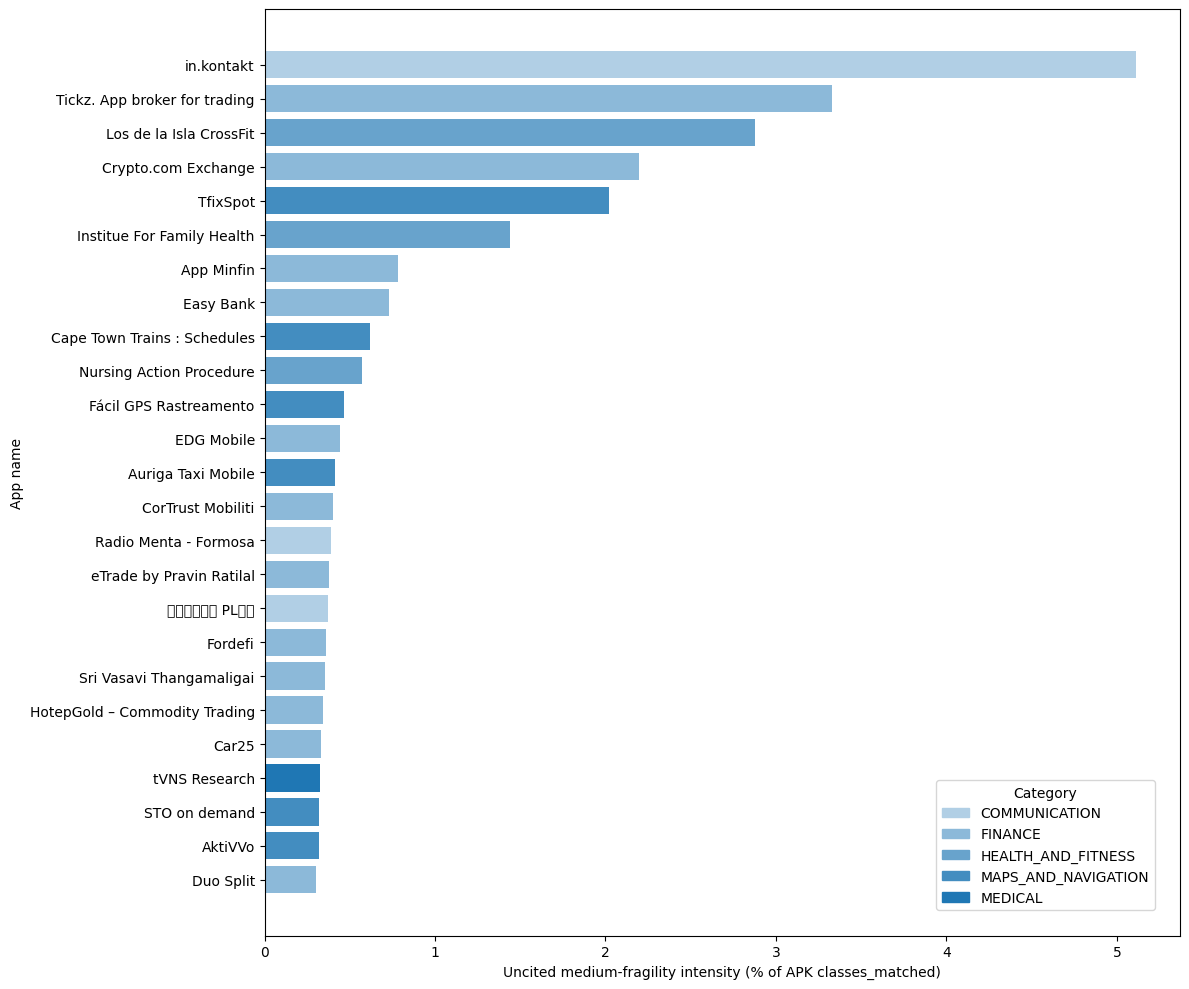

In [77]:
# Top APKs by uncited medium-fragility intensity, using app_name labels and category colors.
plot_df = medium_uncited_apk_usage.head(plot_top_n).sort_values(
    'medium_fragility_uncited_intensity_pct_of_apk', ascending=True
)

plot_category_colored_barh(
    plot_df=plot_df,
    value_col='medium_fragility_uncited_intensity_pct_of_apk',
    title=f'Top {min(plot_top_n, len(plot_df))} apps by uncited medium-fragility usage intensity',
    xlabel='Uncited medium-fragility intensity (% of APK classes_matched)',
    output_filename='top_apps_by_uncited_medium_fragility_intensity.png',
)


### 16.5 Interpretation notes

- `classes_matched` is treated as the available proxy for usage intensity.
- Rows with missing `classes_matched` are counted as `0` for class-based intensity. This avoids inflating intensity from license-text-only evidence where no matched class count is available.
- If one APK has multiple rows for the same repository because several prefixes or fingerprint types matched, this analysis sums those rows because each row represents detected usage evidence in the original dataset.
- `Medium` fragility comes from the `fragility_level` already calculated earlier in this notebook from GitHub repository metadata.